In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create sample datasets for each distribution
np.random.seed(42)

1. BERNOULLI DISTRIBUTION
📚 Distribution Explanation
The Bernoulli distribution is the simplest discrete probability distribution. It models a single experiment with exactly two possible outcomes: success (1) or failure (0).

Key Properties:

Parameter: p = probability of success (0 ≤ p ≤ 1)

Probability Mass Function: P(X = 1) = p, P(X = 0) = 1-p

Mean (Expected Value): E[X] = p

Variance: Var(X) = p(1-p)

Maximum variance: Occurs at p = 0.5 (most uncertainty)

Intuition: Think of a single coin flip. If p = 0.5, it's a fair coin. If p = 0.7, it's weighted toward heads. The Bernoulli distribution answers: "What's the probability of success in this single trial?"

When to Use:

Yes/No decisions

Success/Failure outcomes

Binary classification problems

Any situation with exactly two outcomes

Example 1: Medical Treatment Success
Scenario: A pharmaceutical company develops a new drug with a claimed 70% success rate. Before releasing it, they need to understand the probability distribution of outcomes.

Real-world Context:

Industry: Healthcare/Pharmaceutical

Problem: Predicting treatment outcomes for patients

Stakeholders: Doctors, patients, insurance companies, drug regulators

Why Bernoulli?

Each patient either recovers (success) or doesn't (failure)

Treatment outcome is binary

Success probability is constant (70% based on clinical trials)

Business Impact:

Expected recoveries: 700 out of 1000 patients

Uncertainty range: About 672-728 recoveries (within 1 standard deviation)

Financial planning: Hospitals can budget resources based on expected recovery rates

Risk assessment: 30% of patients may need alternative treatments

Statistical Interpretation:

p = 0.70 means if we treat 1000 patients, we expect about 700 recoveries

The actual number will vary around 700 due to random chance

The variance (p(1-p) = 0.21) indicates moderate uncertainty

Practical Applications:

Hospital resource allocation

Patient counseling (setting realistic expectations)

Insurance premium calculations

Clinical trial planning

BERNOULLI DISTRIBUTION - MEDICAL TREATMENT


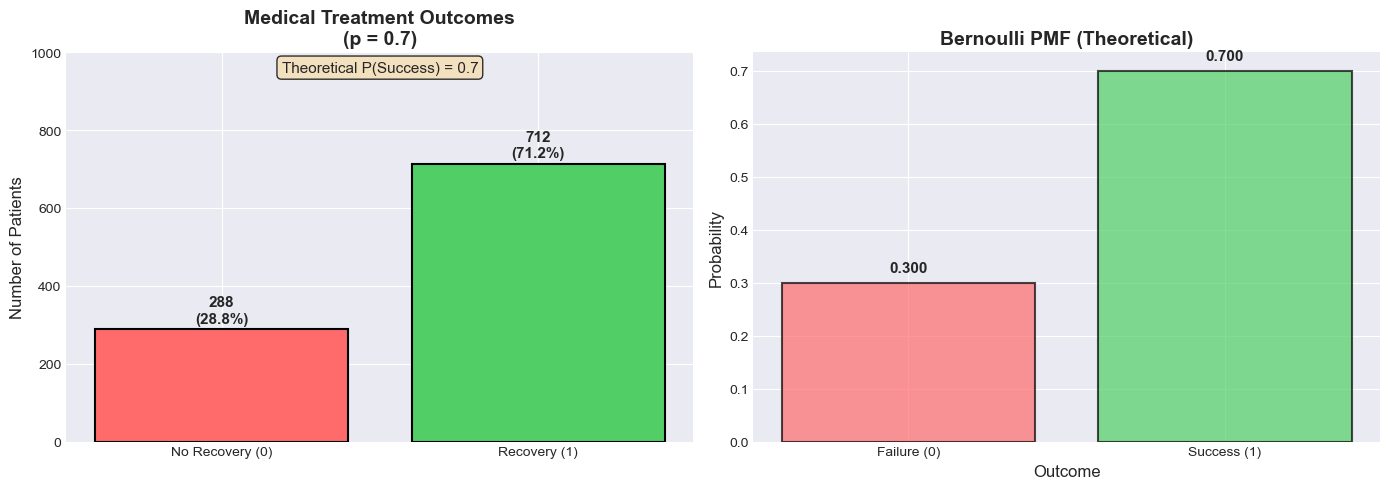


Dataset Statistics:
Total patients: 1000
Recovered: 712
Did not recover: 288
Observed success rate: 0.712
Theoretical success rate: 0.7
Variance (theoretical): 0.210
Variance (observed): 0.205


In [3]:
# Bernoulli Distribution - Medical Treatment Success
print("="*60)
print("BERNOULLI DISTRIBUTION - MEDICAL TREATMENT")
print("="*60)

# Parameters
p_success = 0.70  # 70% success rate
n_patients = 1000

# Generate random dataset: 1 = recovery, 0 = no recovery
treatment_outcomes = np.random.binomial(1, p_success, n_patients)

# Calculate statistics
success_count = np.sum(treatment_outcomes)
failure_count = n_patients - success_count
observed_success_rate = success_count / n_patients

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of outcomes
counts = [failure_count, success_count]
labels = ['No Recovery (0)', 'Recovery (1)']
colors = ['#ff6b6b', '#51cf66']
bars = axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title(f'Medical Treatment Outcomes\n(p = {p_success})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=12)
axes[0].set_ylim(0, n_patients)

# Add value labels on bars
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{count}\n({count/n_patients:.1%})', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add theoretical probabilities
axes[0].text(0.5, 0.95, f'Theoretical P(Success) = {p_success}', 
             transform=axes[0].transAxes, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Probability mass function
k = np.array([0, 1])
pmf = stats.bernoulli.pmf(k, p_success)
axes[1].bar(k, pmf, color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)
axes[1].set_title('Bernoulli PMF (Theoretical)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Failure (0)', 'Success (1)'])

# Add value labels
for i, prob in enumerate(pmf):
    axes[1].text(i, prob + 0.02, f'{prob:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDataset Statistics:")
print(f"Total patients: {n_patients}")
print(f"Recovered: {success_count}")
print(f"Did not recover: {failure_count}")
print(f"Observed success rate: {observed_success_rate:.3f}")
print(f"Theoretical success rate: {p_success}")
print(f"Variance (theoretical): {p_success*(1-p_success):.3f}")
print(f"Variance (observed): {np.var(treatment_outcomes):.3f}")

Example 2: Quality Control (Defective Products)

Scenario: A manufacturing plant produces electronic components with a known 5% defect rate. Quality control engineers need to monitor production quality.

Real-world Context:

Industry: Manufacturing/Electronics

Problem: Identifying defective products before shipment

Stakeholders: Quality control team, production managers, customers

Why Bernoulli?

Each product is either defective or non-defective

5% defect rate is constant (based on historical data)

Independent quality inspection

Business Impact:

Expected defects: 50 out of 1000 products

Cost of defects: If each defect costs $100 to replace, expected loss = $5,000 per 1000 units

Quality targets: Need to keep defect rate below 5% to maintain customer satisfaction

Process improvement: Monitoring helps identify when defect rate increases

Statistical Interpretation:

p = 0.05 means 5% of products are expected to be defective

This is a "rare event" distribution (p small)

Detecting an increase requires sampling multiple products

Practical Applications:

Statistical Process Control (SPC) charts

Acceptance sampling plans

Supplier quality rating

Warranty cost prediction


BERNOULLI DISTRIBUTION - QUALITY CONTROL


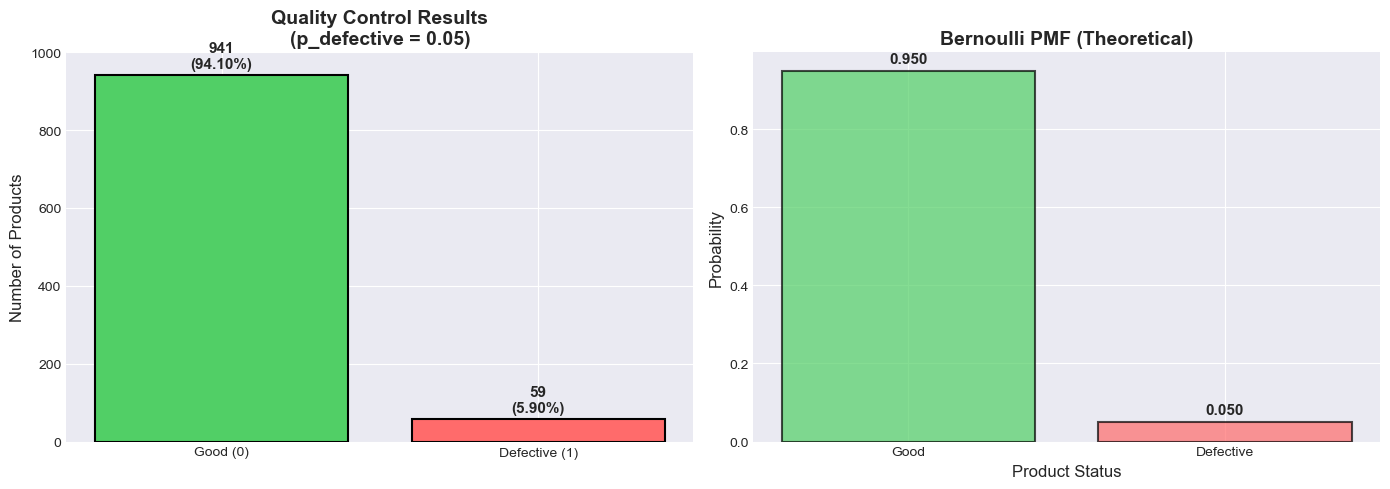


Dataset Statistics:
Total products sampled: 1000
Defective products: 59
Good products: 941
Observed defect rate: 0.0590
Theoretical defect rate: 0.05
Expected defects: 50


In [4]:
# Bernoulli Distribution - Quality Control
print("\n" + "="*60)
print("BERNOULLI DISTRIBUTION - QUALITY CONTROL")
print("="*60)

# Parameters
p_defective = 0.05  # 5% defective rate
sample_size = 1000

# Generate random dataset: 1 = defective, 0 = non-defective
quality_outcomes = np.random.binomial(1, p_defective, sample_size)

# Calculate statistics
defective_count = np.sum(quality_outcomes)
good_count = sample_size - defective_count
observed_defective_rate = defective_count / sample_size

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of outcomes
counts = [good_count, defective_count]
labels = ['Good (0)', 'Defective (1)']
colors = ['#51cf66', '#ff6b6b']
bars = axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title(f'Quality Control Results\n(p_defective = {p_defective})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Products', fontsize=12)
axes[0].set_ylim(0, sample_size)

# Add value labels
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{count}\n({count/sample_size:.2%})', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Probability mass function
k = np.array([0, 1])
pmf = stats.bernoulli.pmf(k, p_defective)
axes[1].bar(k, pmf, color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)
axes[1].set_title('Bernoulli PMF (Theoretical)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Status', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Good', 'Defective'])

# Add value labels
for i, prob in enumerate(pmf):
    axes[1].text(i, prob + 0.02, f'{prob:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDataset Statistics:")
print(f"Total products sampled: {sample_size}")
print(f"Defective products: {defective_count}")
print(f"Good products: {good_count}")
print(f"Observed defect rate: {observed_defective_rate:.4f}")
print(f"Theoretical defect rate: {p_defective}")
print(f"Expected defects: {sample_size * p_defective:.0f}")

2. BINOMIAL DISTRIBUTION

📚 Distribution Explanation

The Binomial distribution generalizes Bernoulli by counting successes across multiple independent trials. If you flip a coin 20 times, how many heads do you get? That's Binomial.

Key Properties:

Parameters:

n = number of trials

p = probability of success per trial

Probability Mass Function: P(X = k) = C(n,k) × p^k × (1-p)^(n-k)

Mean: E[X] = n × p

Variance: Var(X) = n × p × (1-p)

Shape: Symmetric when p = 0.5; skewed when p ≠ 0.5

Intuition: The Binomial is the sum of n independent Bernoulli random variables. It answers: "If I repeat this experiment n times, how many successes will I see?"

When to Use:

Fixed number of trials

Each trial independent

Same probability each time

Counting number of successes

Example 1: Basketball Free Throws
Scenario: A basketball player has 80% free throw accuracy. In a game, they take 20 free throws. How many will they make?

Real-world Context:

Industry: Sports Analytics

Problem: Predicting player performance in games

Stakeholders: Coaches, players, team management, sports bettors

Why Binomial?

Fixed number of attempts (20 free throws)

Each attempt independent (previous shot doesn't affect next)

Same probability (80% accuracy based on training data)

Counting successful shots

Business Impact:

Expected makes: 16 out of 20 shots

Coaching decisions: Should this player be the one taking technical foul shots?

Game strategy: Late-game decisions based on player reliability

Contract negotiations: Higher accuracy leads to higher player value

Statistical Interpretation:

Mean = 16 shots, Standard deviation ≈ √(20×0.8×0.2) = 1.79

About 68% of games: player makes 14-18 shots

About 95% of games: player makes 12-20 shots

Probability of perfect game (20/20): (0.8)^20 ≈ 1.15% (very rare)

Practical Applications:

Player performance evaluation

Game strategy optimization

Player development tracking

Contract valuation


BINOMIAL DISTRIBUTION - BASKETBALL FREE THROWS


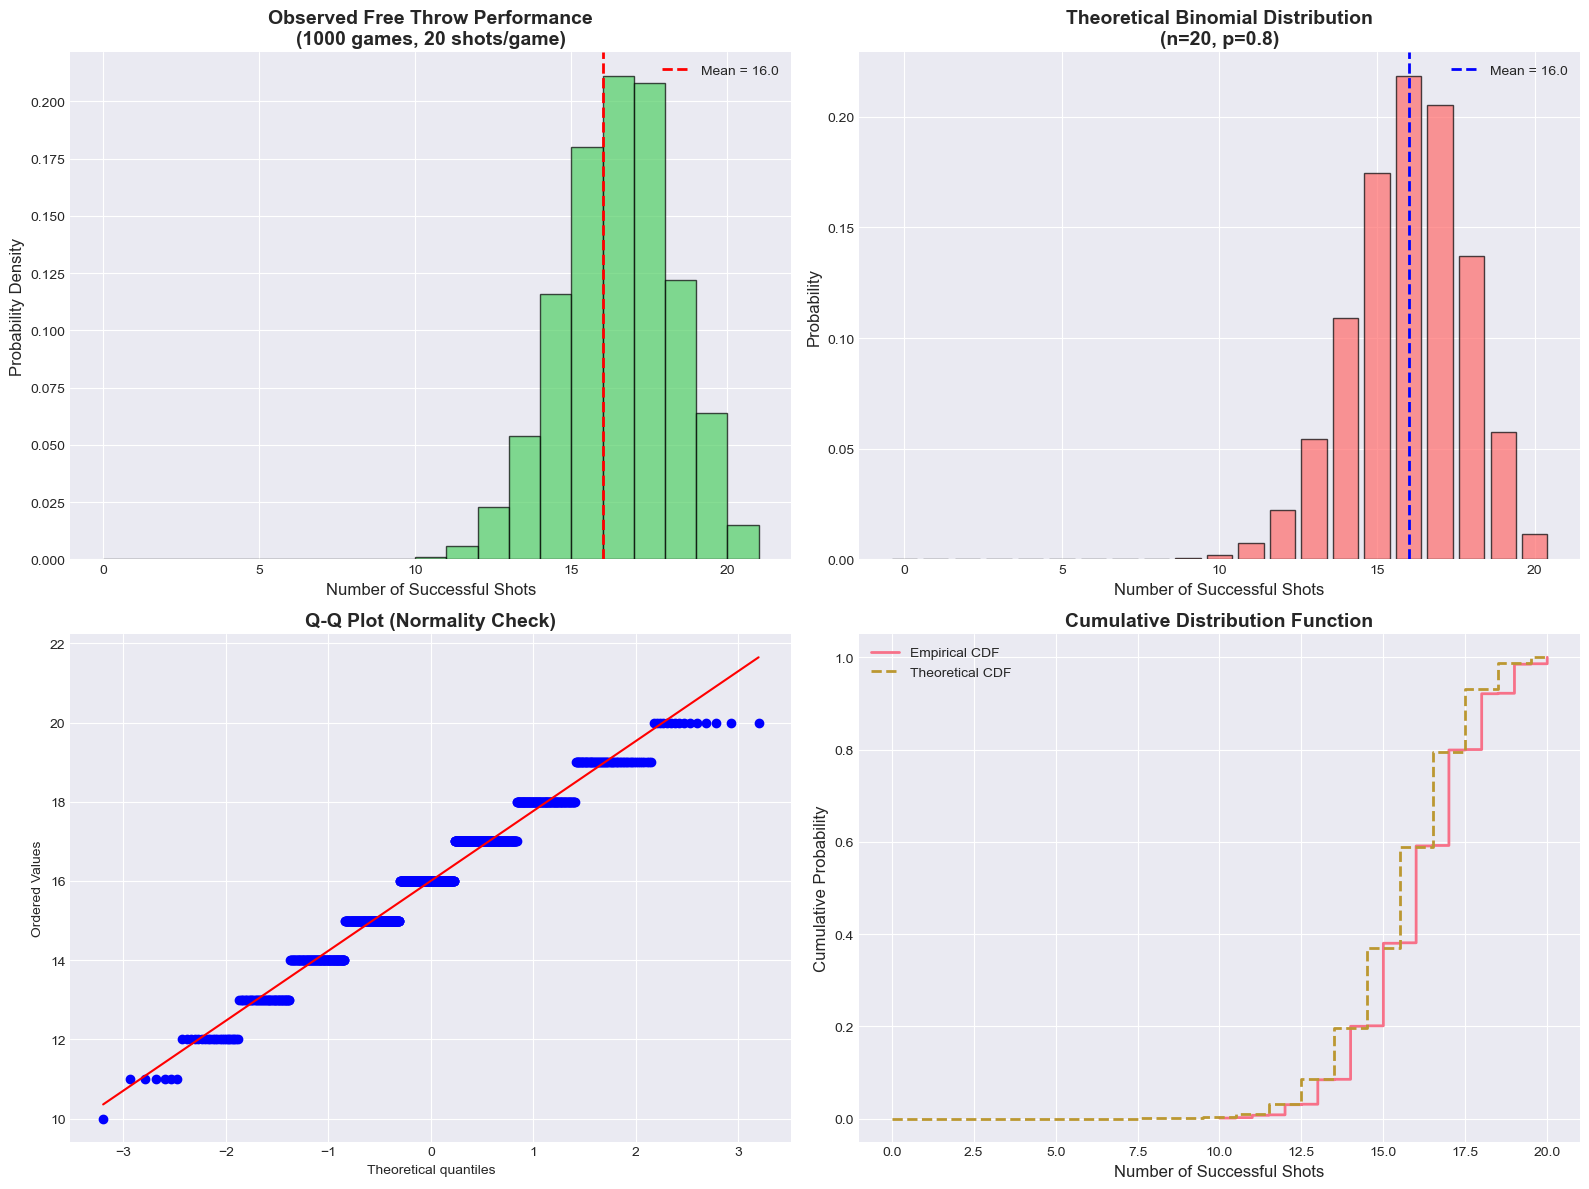


Dataset Statistics:
Number of games simulated: 1000
Observed mean: 16.00
Theoretical mean: 16.00
Observed std dev: 1.79
Theoretical std dev: 1.79
Best game: 20 successful shots
Worst game: 10 successful shots


In [5]:
# Binomial Distribution - Basketball Free Throws
print("\n" + "="*60)
print("BINOMIAL DISTRIBUTION - BASKETBALL FREE THROWS")
print("="*60)

# Parameters
n_shots = 20
p_success = 0.80  # 80% accuracy
n_games = 1000  # Number of games simulated

# Generate random dataset: number of successful shots per game
shots_data = np.random.binomial(n_shots, p_success, n_games)

# Calculate statistics
mean_shots = np.mean(shots_data)
std_shots = np.std(shots_data)
theoretical_mean = n_shots * p_success
theoretical_std = np.sqrt(n_shots * p_success * (1 - p_success))

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram of observed data
axes[0, 0].hist(shots_data, bins=range(0, n_shots+2), alpha=0.7, 
                color='#51cf66', edgecolor='black', density=True)
axes[0, 0].set_title(f'Observed Free Throw Performance\n({n_games} games, {n_shots} shots/game)', 
                     fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Successful Shots', fontsize=12)
axes[0, 0].set_ylabel('Probability Density', fontsize=12)
axes[0, 0].axvline(mean_shots, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean = {mean_shots:.1f}')
axes[0, 0].legend()

# Plot 2: Theoretical PMF
x = np.arange(0, n_shots+1)
pmf = stats.binom.pmf(x, n_shots, p_success)
axes[0, 1].bar(x, pmf, color='#ff6b6b', alpha=0.7, edgecolor='black')
axes[0, 1].set_title(f'Theoretical Binomial Distribution\n(n={n_shots}, p={p_success})', 
                     fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Successful Shots', fontsize=12)
axes[0, 1].set_ylabel('Probability', fontsize=12)
axes[0, 1].axvline(theoretical_mean, color='blue', linestyle='--', linewidth=2,
                   label=f'Mean = {theoretical_mean:.1f}')
axes[0, 1].legend()

# Plot 3: QQ plot for normality check
stats.probplot(shots_data, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')

# Plot 4: Cumulative distribution
x_sorted = np.sort(shots_data)
y_cdf = np.arange(1, len(shots_data)+1) / len(shots_data)
theoretical_cdf = stats.binom.cdf(x, n_shots, p_success)

axes[1, 1].step(x_sorted, y_cdf, where='mid', label='Empirical CDF', linewidth=2)
axes[1, 1].step(x, theoretical_cdf, where='mid', label='Theoretical CDF', 
                linewidth=2, linestyle='--')
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Successful Shots', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nDataset Statistics:")
print(f"Number of games simulated: {n_games}")
print(f"Observed mean: {mean_shots:.2f}")
print(f"Theoretical mean: {theoretical_mean:.2f}")
print(f"Observed std dev: {std_shots:.2f}")
print(f"Theoretical std dev: {theoretical_std:.2f}")
print(f"Best game: {np.max(shots_data)} successful shots")
print(f"Worst game: {np.min(shots_data)} successful shots")

Example 2: Customer Satisfaction Survey

Scenario: A company surveys 50 customers weekly. Historical data shows 65% satisfaction rate. How many satisfied customers can they expect each week?

Real-world Context:

Industry: Market Research/Customer Service

Problem: Tracking customer satisfaction trends

Stakeholders: Management, marketing, customer service teams

Why Binomial?

Fixed number of surveys (50 per week)

Each customer independent

Satisfaction probability constant (65%)

Counting satisfied customers

Business Impact:

Expected satisfaction: 32.5 satisfied customers per week

Quality metric: If satisfaction drops below 60%, investigate issues

Trend analysis: Weekly tracking reveals patterns

Customer retention: 65% satisfaction is baseline for loyalty

Statistical Interpretation:

Mean = 32.5, Standard deviation ≈ √(50×0.65×0.35) = 3.37

95% confidence interval: 32.5 ± 6.6 (26-39 satisfied customers)

This helps detect if a week's results are unusually low

Practical Applications:

Customer satisfaction monitoring

Product improvement tracking

Service quality assessment

Marketing campaign evaluation


BINOMIAL DISTRIBUTION - CUSTOMER SATISFACTION


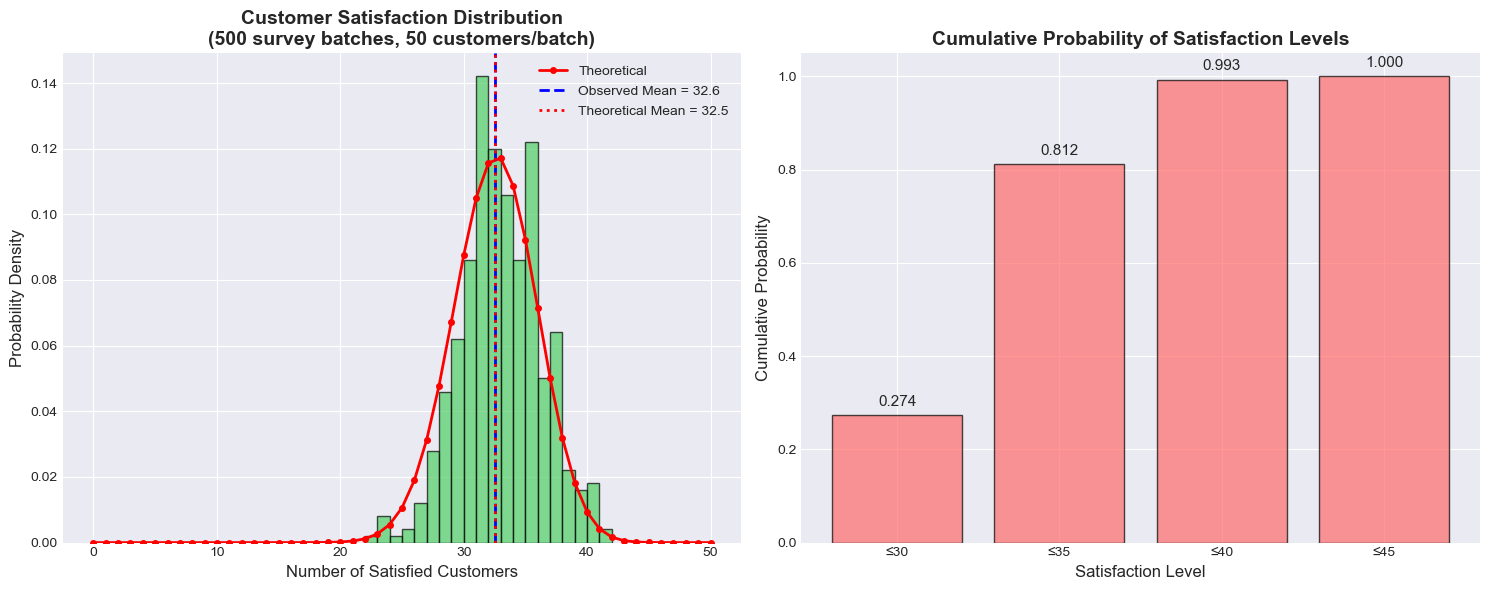


Dataset Statistics:
Number of survey batches: 500
Customers per batch: 50
Observed mean satisfied customers: 32.56
Theoretical mean: 32.50
Observed std dev: 3.29
Theoretical std dev: 3.37
95% confidence interval for satisfaction: [26, 39]


In [6]:
# Binomial Distribution - Customer Satisfaction Survey
print("\n" + "="*60)
print("BINOMIAL DISTRIBUTION - CUSTOMER SATISFACTION")
print("="*60)

# Parameters
n_surveys = 50
p_satisfied = 0.65  # 65% satisfaction rate
n_samples = 500  # Number of survey batches

# Generate random dataset: number of satisfied customers per survey batch
satisfaction_data = np.random.binomial(n_surveys, p_satisfied, n_samples)

# Calculate statistics
mean_satisfied = np.mean(satisfaction_data)
std_satisfied = np.std(satisfaction_data)
theoretical_mean = n_surveys * p_satisfied
theoretical_std = np.sqrt(n_surveys * p_satisfied * (1 - p_satisfied))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Histogram with theoretical overlay
counts, bins, patches = axes[0].hist(satisfaction_data, bins=20, alpha=0.7, 
                                      color='#51cf66', edgecolor='black', density=True)
axes[0].set_title(f'Customer Satisfaction Distribution\n({n_samples} survey batches, {n_surveys} customers/batch)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Satisfied Customers', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)

# Overlay theoretical distribution
x = np.arange(0, n_surveys+1)
pmf = stats.binom.pmf(x, n_surveys, p_satisfied)
axes[0].plot(x, pmf, 'ro-', linewidth=2, markersize=4, label='Theoretical')
axes[0].axvline(mean_satisfied, color='blue', linestyle='--', linewidth=2,
                label=f'Observed Mean = {mean_satisfied:.1f}')
axes[0].axvline(theoretical_mean, color='red', linestyle=':', linewidth=2,
                label=f'Theoretical Mean = {theoretical_mean:.1f}')
axes[0].legend()

# Plot 2: Probability of different satisfaction levels
satisfaction_levels = [30, 35, 40, 45]
probs = [stats.binom.cdf(level, n_surveys, p_satisfied) for level in satisfaction_levels]

x_pos = np.arange(len(satisfaction_levels))
axes[1].bar(x_pos, probs, color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'≤{level}' for level in satisfaction_levels])
axes[1].set_title('Cumulative Probability of Satisfaction Levels', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Satisfaction Level', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)

# Add value labels
for i, prob in enumerate(probs):
    axes[1].text(i, prob + 0.02, f'{prob:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nDataset Statistics:")
print(f"Number of survey batches: {n_samples}")
print(f"Customers per batch: {n_surveys}")
print(f"Observed mean satisfied customers: {mean_satisfied:.2f}")
print(f"Theoretical mean: {theoretical_mean:.2f}")
print(f"Observed std dev: {std_satisfied:.2f}")
print(f"Theoretical std dev: {theoretical_std:.2f}")
print(f"95% confidence interval for satisfaction: [{np.percentile(satisfaction_data, 2.5):.0f}, {np.percentile(satisfaction_data, 97.5):.0f}]")

3. NORMAL DISTRIBUTION

📚 Distribution Explanation

The Normal distribution (Gaussian) is the most important continuous distribution in statistics. The Central Limit Theorem states that averages of many independent variables follow a Normal distribution, regardless of the original distribution.

Key Properties:

Parameters:

μ (mu) = mean (center)

σ (sigma) = standard deviation (spread)

Probability Density Function: f(x) = (1/σ√(2π)) × e^(-(x-μ)²/(2σ²))

Mean = Median = Mode (symmetric)

68-95-99.7 Rule:

68% of data within ±1σ

95% within ±2σ

99.7% within ±3σ

Intuition: Many natural phenomena (heights, test scores, measurement errors) cluster around a central value with symmetric tails.

When to Use:

Natural phenomena (heights, weights)

Measurement errors

Test scores

Any process that's the sum of many small effects

Example 1: Adult Male Heights
Scenario: Adult male heights follow a Normal distribution with mean 175 cm and standard deviation 7 cm. This is used for clothing manufacturing, ergonomic design, and medical studies.

Real-world Context:

Industry: Apparel, Healthcare, Ergonomics

Problem: Designing products that fit most people

Stakeholders: Manufacturers, designers, healthcare professionals

Why Normal?

Height is determined by many genetic and environmental factors

The Central Limit Theorem applies (sum of many small effects)

Real data confirms Normal distribution

The 68-95-99.7 Rule Applied:

68% of men: 168-182 cm (within 1σ)

95% of men: 161-189 cm (within 2σ)

99.7% of men: 154-196 cm (within 3σ)

Business Impact:

Clothing manufacturing: Size ranges based on these percentiles

Door frame design: 99.7% of men fit through 196 cm doors

Medical assessment: Identifying growth abnormalities

Furniture design: Ergonomic adjustments

Statistical Interpretation:

Z-score = (x - μ)/σ standardizes any height to a common scale

Example: 189 cm height → Z = (189-175)/7 = 2.0

This is exactly 2 standard deviations above the mean (95th percentile)

Practical Applications:

Clothing size charts

Ergonomic workplace design

Medical growth charts

Anthropometric studies



In [10]:
# Normal Distribution - Adult Male Heights (Fixed Version)
print("\n" + "="*60)
print("NORMAL DISTRIBUTION - ADULT MALE HEIGHTS")
print("="*60)

# Parameters
mu_height = 175  # cm
sigma_height = 7  # cm
n_people = 10000

# Generate random dataset
heights = np.random.normal(mu_height, sigma_height, n_people)

# Calculate statistics
mean_height = np.mean(heights)
std_height = np.std(heights)

# Create visualization with better layout
fig = plt.figure(figsize=(16, 12))

# Plot 1: Histogram with fitted normal curve
ax1 = plt.subplot(2, 2, 1)
ax1.hist(heights, bins=50, density=True, alpha=0.7, color='#51cf66', edgecolor='black')
x = np.linspace(mu_height - 4*sigma_height, mu_height + 4*sigma_height, 100)
pdf = stats.norm.pdf(x, mu_height, sigma_height)
ax1.plot(x, pdf, 'r-', linewidth=2, label='Theoretical Normal')
ax1.axvline(mean_height, color='blue', linestyle='--', linewidth=2, 
            label=f'Mean = {mean_height:.1f} cm')
ax1.set_title('Distribution of Adult Male Heights', fontsize=14, fontweight='bold')
ax1.set_xlabel('Height (cm)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Empirical Rule visualization
ax2 = plt.subplot(2, 2, 2)
ax2.hist(heights, bins=50, density=True, alpha=0.5, color='lightblue')
ax2.plot(x, pdf, 'r-', linewidth=2)

# Shade areas for empirical rule
for low, high, label, color in [(mu_height - sigma_height, mu_height + sigma_height, '68%', 'green'),
                                  (mu_height - 2*sigma_height, mu_height + 2*sigma_height, '95%', 'yellow'),
                                  (mu_height - 3*sigma_height, mu_height + 3*sigma_height, '99.7%', 'orange')]:
    mask = (x >= low) & (x <= high)
    ax2.fill_between(x[mask], pdf[mask], alpha=0.3, label=label)

ax2.set_title('Empirical Rule (68-95-99.7)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Height (cm)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Plot 3: QQ plot
ax3 = plt.subplot(2, 2, 3)
stats.probplot(heights, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Box plot with percentiles
ax4 = plt.subplot(2, 2, 4)
box_data = [heights]
bp = ax4.boxplot(box_data, patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#ff6b6b')
bp['boxes'][0].set_alpha(0.7)
ax4.set_title('Height Distribution Summary', fontsize=14, fontweight='bold')
ax4.set_ylabel('Height (cm)', fontsize=12)
ax4.set_xticklabels(['Male Heights'])

# Add statistics text
stats_text = f'Mean: {mean_height:.1f} cm\nStd: {std_height:.1f} cm\nMedian: {np.median(heights):.1f} cm'
ax4.text(1.1, np.percentile(heights, 75), stats_text, 
         transform=ax4.get_xaxis_transform(), fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Alternative: Adjust layout manually
plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.08, wspace=0.25, hspace=0.35)
plt.show()

print(f"\nDataset Statistics:")
print(f"Number of individuals: {n_people}")
print(f"Mean height: {mean_height:.2f} cm")
print(f"Standard deviation: {std_height:.2f} cm")
print(f"Median height: {np.median(heights):.2f} cm")
print(f"Skewness: {stats.skew(heights):.3f}")
print(f"Kurtosis: {stats.kurtosis(heights):.3f}")

# Calculate empirical rule percentages
within_1sigma = np.sum(np.abs(heights - mu_height) <= sigma_height) / n_people * 100
within_2sigma = np.sum(np.abs(heights - mu_height) <= 2*sigma_height) / n_people * 100
within_3sigma = np.sum(np.abs(heights - mu_height) <= 3*sigma_height) / n_people * 100

print(f"\nEmpirical Rule Check:")
print(f"Within 1σ: {within_1sigma:.1f}% (expected 68%)")
print(f"Within 2σ: {within_2sigma:.1f}% (expected 95%)")
print(f"Within 3σ: {within_3sigma:.1f}% (expected 99.7%)")

# Additional statistics for outliers
q1 = np.percentile(heights, 25)
q3 = np.percentile(heights, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = heights[(heights < lower_bound) | (heights > upper_bound)]

print(f"\nOutlier Analysis:")
print(f"Q1 (25th percentile): {q1:.1f} cm")
print(f"Q3 (75th percentile): {q3:.1f} cm")
print(f"IQR: {iqr:.1f} cm")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/n_people*100:.1f}%)")
print(f"Outlier range: < {lower_bound:.1f} cm or > {upper_bound:.1f} cm")


NORMAL DISTRIBUTION - ADULT MALE HEIGHTS



Dataset Statistics:
Number of individuals: 10000
Mean height: 175.01 cm
Standard deviation: 7.02 cm
Median height: 175.00 cm
Skewness: -0.009
Kurtosis: -0.074

Empirical Rule Check:
Within 1σ: 67.6% (expected 68%)
Within 2σ: 95.6% (expected 95%)
Within 3σ: 99.8% (expected 99.7%)

Outlier Analysis:
Q1 (25th percentile): 170.2 cm
Q3 (75th percentile): 179.8 cm
IQR: 9.6 cm
Number of outliers: 54 (0.5%)
Outlier range: < 155.8 cm or > 194.2 cm


Example 2: IQ Scores

Scenario: IQ scores are standardized to follow a Normal distribution with mean 100 and standard deviation 15. This is used in education, psychology, and clinical assessments.

Real-world Context:

Industry: Education, Psychology, Clinical Assessment

Problem: Measuring cognitive ability and identifying needs

Stakeholders: Psychologists, educators, parents, employers

Why Normal?

IQ tests are designed to be Normally distributed

Standardization ensures μ=100, σ=15

Allows comparison across populations

Interpretation of Scores:

Below 70: Very low (2.3% of population)

70-85: Low (13.6% of population)

85-115: Average (68% of population)

115-130: High (13.6% of population)

Above 130: Very high (2.3% of population)

Business Impact:

Education: Gifted programs for students with IQ > 130

Employment: Some jobs have minimum cognitive requirements

Research: Understanding population distributions

Healthcare: Identifying intellectual disabilities

Statistical Interpretation:

Z-score = (IQ - 100)/15

IQ 130 → Z = 2.0 → 97.7th percentile

IQ 70 → Z = -2.0 → 2.3rd percentile

Practical Applications:

Educational placement

Clinical diagnosis

Research studies

Job candidate screening


NORMAL DISTRIBUTION - IQ SCORES


C:\Users\ART\AppData\Local\Temp\ipykernel_12880\276416515.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(category_scores, labels=category_labels, patch_artist=True)


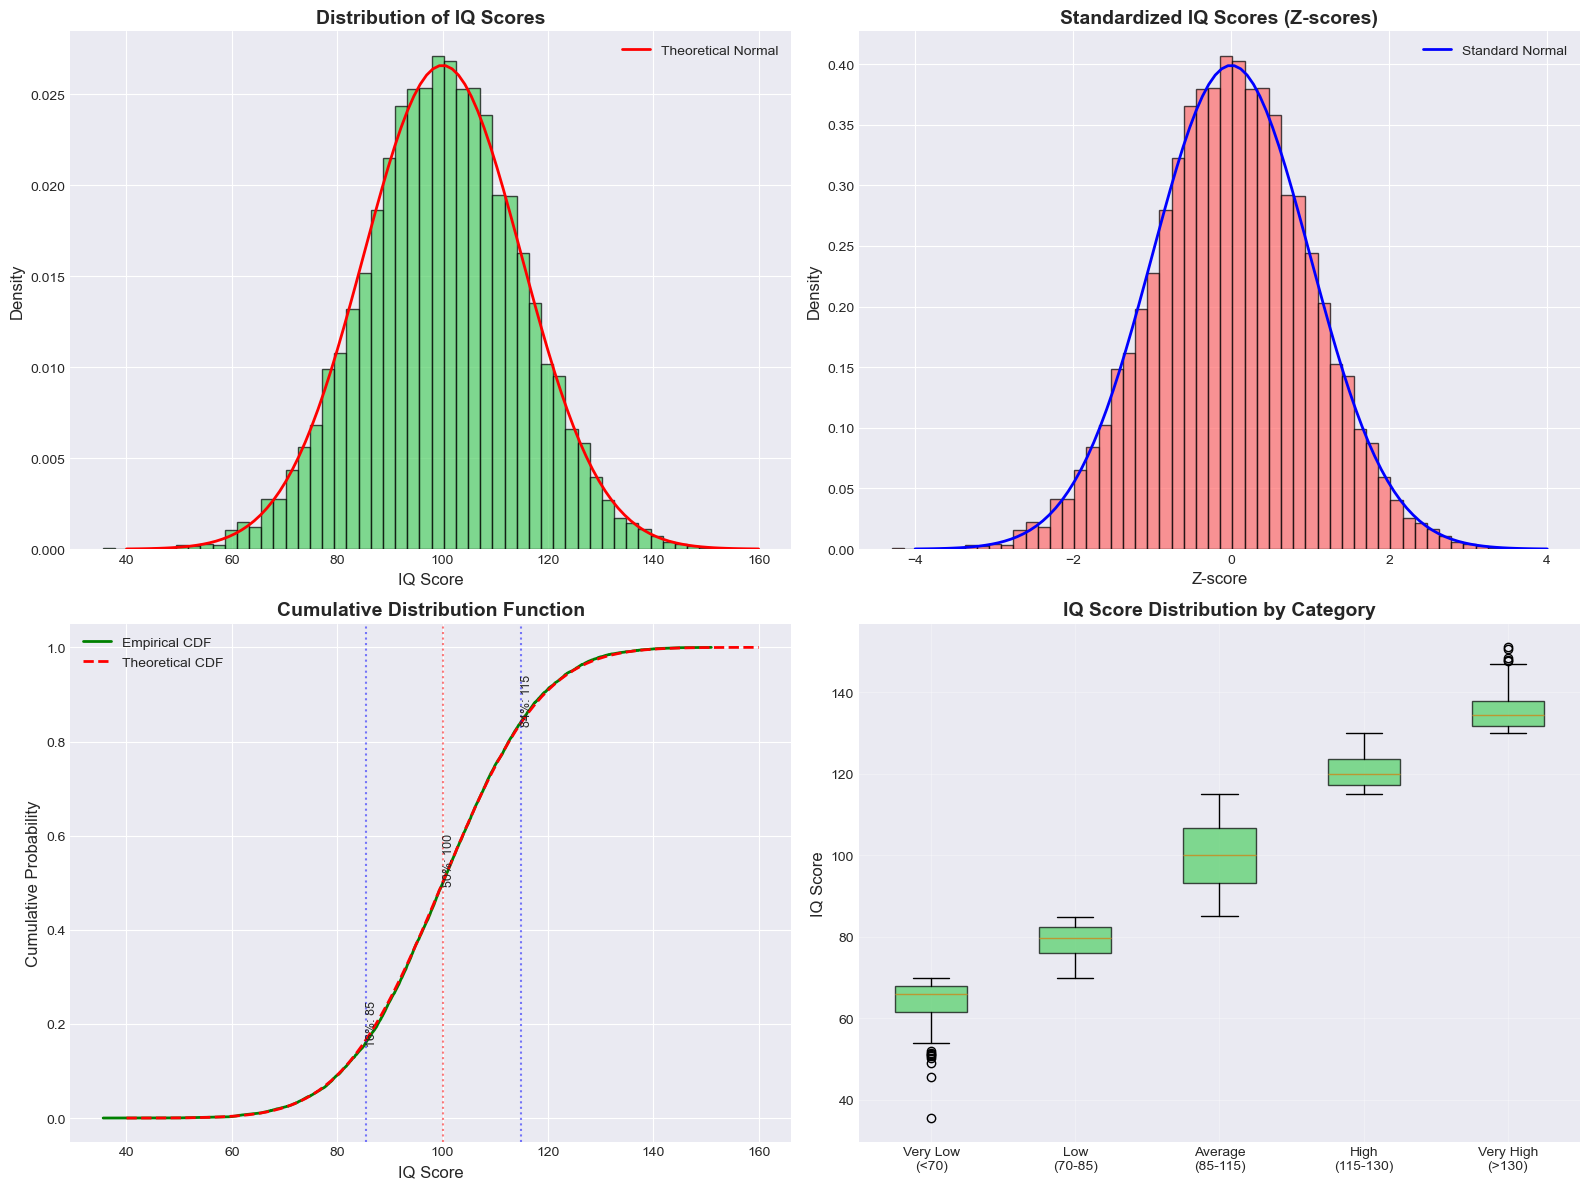


Dataset Statistics:
Number of individuals: 10000
Mean IQ: 100.02
Standard deviation: 14.87
Median IQ: 100.08

IQ Category Distribution:
Very Low
(<70): 232 (2.3%)
Low
(70-85): 1293 (12.9%)
Average
(85-115): 6910 (69.1%)
High
(115-130): 1363 (13.6%)
Very High
(>130): 202 (2.0%)


In [11]:
# Normal Distribution - IQ Scores
print("\n" + "="*60)
print("NORMAL DISTRIBUTION - IQ SCORES")
print("="*60)

# Parameters
mu_iq = 100
sigma_iq = 15
n_people = 10000

# Generate random dataset
iq_scores = np.random.normal(mu_iq, sigma_iq, n_people)

# Calculate statistics
mean_iq = np.mean(iq_scores)
std_iq = np.std(iq_scores)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram with theoretical curve
axes[0, 0].hist(iq_scores, bins=50, density=True, alpha=0.7, color='#51cf66', edgecolor='black')
x = np.linspace(mu_iq - 4*sigma_iq, mu_iq + 4*sigma_iq, 100)
pdf = stats.norm.pdf(x, mu_iq, sigma_iq)
axes[0, 0].plot(x, pdf, 'r-', linewidth=2, label='Theoretical Normal')
axes[0, 0].set_title('Distribution of IQ Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('IQ Score', fontsize=12)
axes[0, 0].set_ylabel('Density', fontsize=12)
axes[0, 0].legend()

# Plot 2: Z-score transformation
z_scores = (iq_scores - mu_iq) / sigma_iq
axes[0, 1].hist(z_scores, bins=50, density=True, alpha=0.7, color='#ff6b6b', edgecolor='black')
x_z = np.linspace(-4, 4, 100)
pdf_z = stats.norm.pdf(x_z, 0, 1)
axes[0, 1].plot(x_z, pdf_z, 'b-', linewidth=2, label='Standard Normal')
axes[0, 1].set_title('Standardized IQ Scores (Z-scores)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Z-score', fontsize=12)
axes[0, 1].set_ylabel('Density', fontsize=12)
axes[0, 1].legend()

# Plot 3: Cumulative distribution with percentiles
x_sorted = np.sort(iq_scores)
y_cdf = np.arange(1, len(iq_scores)+1) / len(iq_scores)
axes[1, 0].plot(x_sorted, y_cdf, 'g-', linewidth=2, label='Empirical CDF')
theoretical_cdf = stats.norm.cdf(x, mu_iq, sigma_iq)
axes[1, 0].plot(x, theoretical_cdf, 'r--', linewidth=2, label='Theoretical CDF')

# Mark key percentiles
for percentile, color in [(0.16, 'blue'), (0.5, 'red'), (0.84, 'blue')]:
    value = np.percentile(iq_scores, percentile*100)
    axes[1, 0].axvline(value, color=color, linestyle=':', alpha=0.5)
    axes[1, 0].text(value, percentile, f'{percentile*100:.0f}%: {value:.0f}', 
                    rotation=90, fontsize=9)

axes[1, 0].set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('IQ Score', fontsize=12)
axes[1, 0].set_ylabel('Cumulative Probability', fontsize=12)
axes[1, 0].legend()

# Plot 4: Box plot by IQ categories
categories = ['Very Low\n(<70)', 'Low\n(70-85)', 'Average\n(85-115)', 'High\n(115-130)', 'Very High\n(>130)']
bounds = [-np.inf, 70, 85, 115, 130, np.inf]
category_scores = []
category_labels = []

for i in range(len(bounds)-1):
    mask = (iq_scores >= bounds[i]) & (iq_scores < bounds[i+1])
    if np.sum(mask) > 0:
        category_scores.append(iq_scores[mask])
        category_labels.append(categories[i])

bp = axes[1, 1].boxplot(category_scores, labels=category_labels, patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor('#51cf66')
    box.set_alpha(0.7)
axes[1, 1].set_title('IQ Score Distribution by Category', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('IQ Score', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDataset Statistics:")
print(f"Number of individuals: {n_people}")
print(f"Mean IQ: {mean_iq:.2f}")
print(f"Standard deviation: {std_iq:.2f}")
print(f"Median IQ: {np.median(iq_scores):.2f}")

# Calculate percentage in each category
print(f"\nIQ Category Distribution:")
for i in range(len(bounds)-1):
    count = np.sum((iq_scores >= bounds[i]) & (iq_scores < bounds[i+1]))
    percentage = count / n_people * 100
    print(f"{categories[i]}: {count} ({percentage:.1f}%)")

4. POISSON DISTRIBUTION
📚 Distribution Explanation
The Poisson distribution models the number of events occurring in a fixed interval of time or space when events happen independently at a constant average rate.

Key Properties:

Parameter: λ (lambda) = average number of events per interval

Probability Mass Function: P(X = k) = (λ^k × e^(-λ)) / k!

Mean = Variance = λ (unique property!)

Shape: Skewed right for small λ; approaches Normal as λ grows

Intuition: Counts of rare events: earthquakes, accidents, calls to a call center, typos on a page.

When to Use:

Counting events over time/space

Events occur independently

Rate is constant

Events are rare relative to interval

Example 1: Call Center Calls
Scenario: A call center receives an average of 5 calls per hour. Understanding this distribution helps with staffing and service level planning.

Real-world Context:

Industry: Customer Service/Telecommunications

Problem: Optimizing staffing levels

Stakeholders: Operations managers, customer service agents, customers

Why Poisson?

Calls arrive independently (no caller affects another)

Average rate constant (5 calls/hour based on historical data)

Calls are relatively rare in short intervals

Counting number of calls

Business Impact:

Mean calls: 5 per hour

Staffing: Need enough agents to handle peak hours

Service Level: P(≤5 calls) = 61.6% (can handle without delay)

Understaffing risk: P(>8 calls) = 8.9%

Statistical Interpretation:

P(X=0) = e^(-5) = 0.67% (very rare to have zero calls)

P(X=5) = 5^5 × e^(-5)/120 = 17.5% (most likely outcome)

95% of hours: 2-9 calls (within 2 standard deviations)

Practical Applications:

Call center staffing optimization

Service level agreement planning

Peak hour preparation

Cost-benefit analysis of hiring


POISSON DISTRIBUTION - CALL CENTER


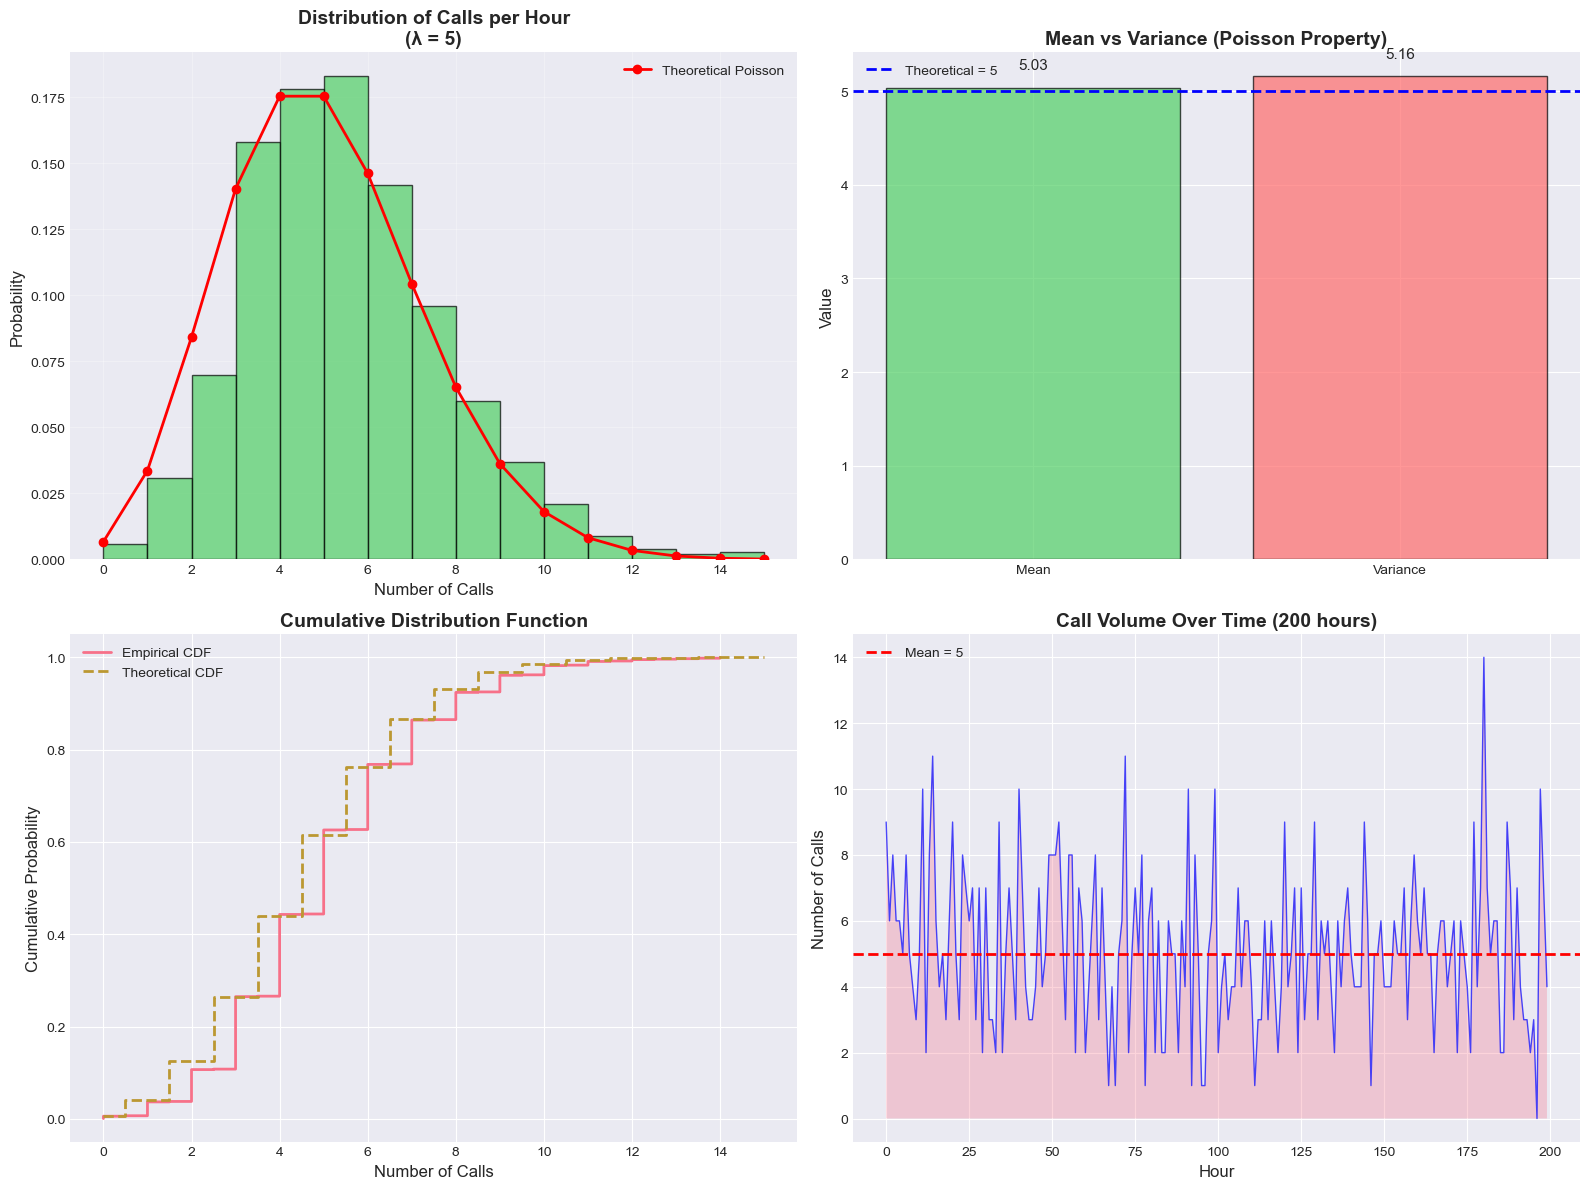


Dataset Statistics:
Number of hours observed: 1000
Observed mean: 5.03
Theoretical mean: 5
Observed variance: 5.16
Theoretical variance: 5.00
Maximum calls in an hour: 14
Minimum calls in an hour: 0

Probability of:
0 calls in an hour: 0.007
5 calls in an hour: 0.175
10+ calls in an hour: 0.032


In [12]:
# Poisson Distribution - Call Center Calls
print("\n" + "="*60)
print("POISSON DISTRIBUTION - CALL CENTER")
print("="*60)

# Parameters
lambda_calls = 5  # average calls per hour
n_hours = 1000

# Generate random dataset
calls_data = np.random.poisson(lambda_calls, n_hours)

# Calculate statistics
mean_calls = np.mean(calls_data)
var_calls = np.var(calls_data)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram with theoretical PMF
counts, bins, patches = axes[0, 0].hist(calls_data, bins=range(0, 16), 
                                         alpha=0.7, color='#51cf66', edgecolor='black', density=True)
x = np.arange(0, 16)
pmf = stats.poisson.pmf(x, lambda_calls)
axes[0, 0].plot(x, pmf, 'ro-', linewidth=2, markersize=6, label='Theoretical Poisson')
axes[0, 0].set_title(f'Distribution of Calls per Hour\n(λ = {lambda_calls})', 
                     fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Calls', fontsize=12)
axes[0, 0].set_ylabel('Probability', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Comparison of mean and variance
theoretical_var = lambda_calls
axes[0, 1].bar(['Mean', 'Variance'], [mean_calls, var_calls], 
               color=['#51cf66', '#ff6b6b'], edgecolor='black', alpha=0.7)
axes[0, 1].axhline(lambda_calls, color='blue', linestyle='--', linewidth=2, label=f'Theoretical = {lambda_calls}')
axes[0, 1].set_title('Mean vs Variance (Poisson Property)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Value', fontsize=12)
axes[0, 1].legend()

# Add value labels
axes[0, 1].text(0, mean_calls + 0.2, f'{mean_calls:.2f}', ha='center', fontsize=11)
axes[0, 1].text(1, var_calls + 0.2, f'{var_calls:.2f}', ha='center', fontsize=11)

# Plot 3: Cumulative distribution
x_sorted = np.sort(calls_data)
y_cdf = np.arange(1, len(calls_data)+1) / len(calls_data)
theoretical_cdf = stats.poisson.cdf(x, lambda_calls)

axes[1, 0].step(x_sorted, y_cdf, where='mid', label='Empirical CDF', linewidth=2)
axes[1, 0].step(x, theoretical_cdf, where='mid', label='Theoretical CDF', linewidth=2, linestyle='--')
axes[1, 0].set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Calls', fontsize=12)
axes[1, 0].set_ylabel('Cumulative Probability', fontsize=12)
axes[1, 0].legend()

# Plot 4: Time series simulation
hours = np.arange(200)
calls_series = np.random.poisson(lambda_calls, 200)
axes[1, 1].plot(hours, calls_series, 'b-', alpha=0.7, linewidth=1)
axes[1, 1].fill_between(hours, calls_series, alpha=0.3)
axes[1, 1].axhline(lambda_calls, color='red', linestyle='--', linewidth=2, label=f'Mean = {lambda_calls}')
axes[1, 1].set_title('Call Volume Over Time (200 hours)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Hour', fontsize=12)
axes[1, 1].set_ylabel('Number of Calls', fontsize=12)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nDataset Statistics:")
print(f"Number of hours observed: {n_hours}")
print(f"Observed mean: {mean_calls:.2f}")
print(f"Theoretical mean: {lambda_calls}")
print(f"Observed variance: {var_calls:.2f}")
print(f"Theoretical variance: {theoretical_var:.2f}")
print(f"Maximum calls in an hour: {np.max(calls_data)}")
print(f"Minimum calls in an hour: {np.min(calls_data)}")

# Calculate probability of different scenarios
print(f"\nProbability of:")
print(f"0 calls in an hour: {stats.poisson.pmf(0, lambda_calls):.3f}")
print(f"5 calls in an hour: {stats.poisson.pmf(5, lambda_calls):.3f}")
print(f"10+ calls in an hour: {1 - stats.poisson.cdf(9, lambda_calls):.3f}")

Example 2: Website Server Errors

Scenario: A website experiences an average of 3 server errors per day. Monitoring this helps with infrastructure planning and service reliability.

Real-world Context:

Industry: Technology/Web Services

Problem: Maintaining service reliability

Stakeholders: IT operations, developers, business owners, users

Why Poisson?

Errors occur independently

Average rate constant (3/day based on monitoring)

Rare events relative to the observation window

Business Impact:

Expected errors: 3 per day

SLA Targets: Need 95% of days with ≤5 errors

Reliability: P(≥10 errors) = 0.04% (rare, but if it occurs, investigate)

Cost impact: Each error may affect customer experience

Statistical Interpretation:

P(X=0) = e^(-3) = 4.98% (about 5 days per 100 have no errors)

P(X≤5) = 91.6% (meets most SLAs)

P(X>8) = 0.38% (very rare anomalies)

Practical Applications:

Server capacity planning

Error monitoring and alerting

Service level agreement compliance

Infrastructure investment justification


POISSON DISTRIBUTION - WEBSITE SERVER ERRORS


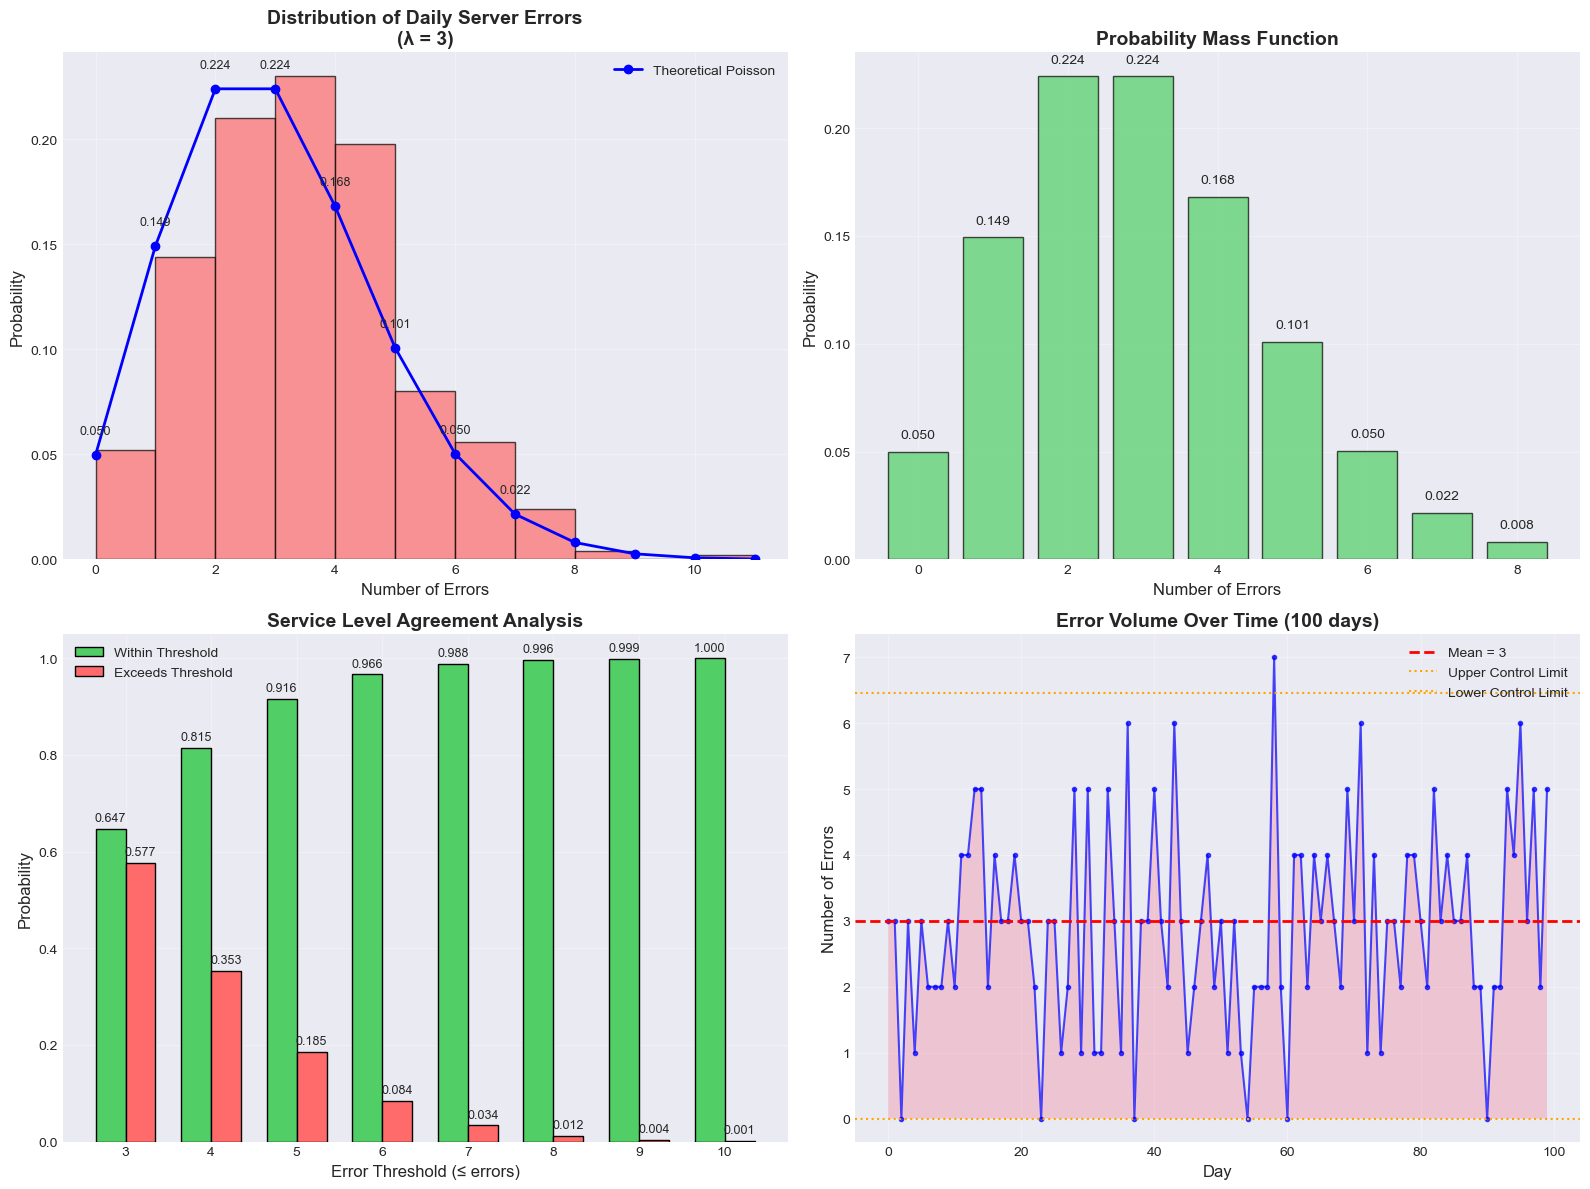


DATASET STATISTICS
Number of days observed: 500
Total errors: 1501
Observed mean: 3.00
Theoretical mean: 3
Observed variance: 2.86
Theoretical variance: 3.00
Median errors per day: 3
Maximum errors in a day: 10
Minimum errors in a day: 0

PROBABILITY ANALYSIS
Probability of 0 errors: 0.0498 (4.98%)
Probability of 3 errors: 0.2240 (22.40%)
Probability of 5 errors: 0.1008 (10.08%)
Probability of ≤5 errors: 0.9161 (91.61%)
Probability of ≥10 errors: 0.0011 (0.11%)

SERVICE LEVEL AGREEMENT (SLA) ANALYSIS
SLA: ≤3 errors/day
  - Meets SLA: 0.647 (64.7%)
  - Violates SLA: 0.353 (35.3%)

SLA: ≤4 errors/day
  - Meets SLA: 0.815 (81.5%)
  - Violates SLA: 0.185 (18.5%)

SLA: ≤5 errors/day
  - Meets SLA: 0.916 (91.6%)
  - Violates SLA: 0.084 (8.4%)

SLA: ≤6 errors/day
  - Meets SLA: 0.966 (96.6%)
  - Violates SLA: 0.034 (3.4%)

SLA: ≤7 errors/day
  - Meets SLA: 0.988 (98.8%)
  - Violates SLA: 0.012 (1.2%)

ANOMALY DETECTION
Control limits: [0.0, 6.5]
Number of anomalous days: 15 (3.0%)
Anomalous 

In [14]:
# Poisson Distribution - Website Server Errors (Complete)
print("\n" + "="*60)
print("POISSON DISTRIBUTION - WEBSITE SERVER ERRORS")
print("="*60)

# Parameters
lambda_errors = 3  # average errors per day
n_days = 500

# Generate random dataset
errors_data = np.random.poisson(lambda_errors, n_days)

# Calculate statistics
mean_errors = np.mean(errors_data)
var_errors = np.var(errors_data)
median_errors = np.median(errors_data)

# Create visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: Histogram with theoretical PMF
ax1 = plt.subplot(2, 2, 1)
counts, bins, patches = ax1.hist(errors_data, bins=range(0, 12), 
                                  alpha=0.7, color='#ff6b6b', edgecolor='black', density=True)
x = np.arange(0, 12)
pmf = stats.poisson.pmf(x, lambda_errors)
ax1.plot(x, pmf, 'bo-', linewidth=2, markersize=6, label='Theoretical Poisson')
ax1.set_title(f'Distribution of Daily Server Errors\n(λ = {lambda_errors})', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Errors', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on theoretical points
for i, prob in enumerate(pmf[:8]):
    ax1.text(i, prob + 0.01, f'{prob:.3f}', ha='center', fontsize=9)

# Plot 2: Probability of different error levels
ax2 = plt.subplot(2, 2, 2)
error_levels = [0, 1, 2, 3, 4, 5, 6, 7, 8]
probs = [stats.poisson.pmf(k, lambda_errors) for k in error_levels]

bars = ax2.bar(error_levels, probs, color='#51cf66', edgecolor='black', alpha=0.7)
ax2.set_title('Probability Mass Function', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Errors', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)

# Add value labels
for bar, prob in zip(bars, probs):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{prob:.3f}', ha='center', va='bottom', fontsize=10)

ax2.grid(True, alpha=0.3)

# Plot 3: Cumulative probability for service level agreement
ax3 = plt.subplot(2, 2, 3)
error_thresholds = [3, 4, 5, 6, 7, 8, 9, 10]
prob_exceed = [1 - stats.poisson.cdf(t-1, lambda_errors) for t in error_thresholds]
prob_within = [stats.poisson.cdf(t, lambda_errors) for t in error_thresholds]

x_pos = np.arange(len(error_thresholds))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, prob_within, width, label='Within Threshold', color='#51cf66', edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, prob_exceed, width, label='Exceeds Threshold', color='#ff6b6b', edgecolor='black')

ax3.set_xlabel('Error Threshold (≤ errors)', fontsize=12)
ax3.set_ylabel('Probability', fontsize=12)
ax3.set_title('Service Level Agreement Analysis', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(error_thresholds)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Time series simulation
ax4 = plt.subplot(2, 2, 4)
hours = np.arange(100)
errors_series = np.random.poisson(lambda_errors, 100)

ax4.plot(hours, errors_series, 'b-', alpha=0.7, linewidth=1.5, marker='o', markersize=3)
ax4.fill_between(hours, errors_series, alpha=0.3)
ax4.axhline(lambda_errors, color='red', linestyle='--', linewidth=2, 
            label=f'Mean = {lambda_errors}')
ax4.axhline(lambda_errors + 2*np.sqrt(lambda_errors), color='orange', linestyle=':', 
            linewidth=1.5, label='Upper Control Limit')
ax4.axhline(max(0, lambda_errors - 2*np.sqrt(lambda_errors)), color='orange', 
            linestyle=':', linewidth=1.5, label='Lower Control Limit')
ax4.set_title('Error Volume Over Time (100 days)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Day', fontsize=12)
ax4.set_ylabel('Number of Errors', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("DATASET STATISTICS")
print(f"{'='*60}")
print(f"Number of days observed: {n_days}")
print(f"Total errors: {np.sum(errors_data)}")
print(f"Observed mean: {mean_errors:.2f}")
print(f"Theoretical mean: {lambda_errors}")
print(f"Observed variance: {var_errors:.2f}")
print(f"Theoretical variance: {lambda_errors:.2f}")
print(f"Median errors per day: {median_errors:.0f}")
print(f"Maximum errors in a day: {np.max(errors_data)}")
print(f"Minimum errors in a day: {np.min(errors_data)}")

print(f"\n{'='*60}")
print("PROBABILITY ANALYSIS")
print(f"{'='*60}")
print(f"Probability of 0 errors: {stats.poisson.pmf(0, lambda_errors):.4f} ({stats.poisson.pmf(0, lambda_errors)*100:.2f}%)")
print(f"Probability of 3 errors: {stats.poisson.pmf(3, lambda_errors):.4f} ({stats.poisson.pmf(3, lambda_errors)*100:.2f}%)")
print(f"Probability of 5 errors: {stats.poisson.pmf(5, lambda_errors):.4f} ({stats.poisson.pmf(5, lambda_errors)*100:.2f}%)")
print(f"Probability of ≤5 errors: {stats.poisson.cdf(5, lambda_errors):.4f} ({stats.poisson.cdf(5, lambda_errors)*100:.2f}%)")
print(f"Probability of ≥10 errors: {1 - stats.poisson.cdf(9, lambda_errors):.4f} ({(1 - stats.poisson.cdf(9, lambda_errors))*100:.2f}%)")

print(f"\n{'='*60}")
print("SERVICE LEVEL AGREEMENT (SLA) ANALYSIS")
print(f"{'='*60}")
for threshold in [3, 4, 5, 6, 7]:
    prob_within = stats.poisson.cdf(threshold, lambda_errors)
    prob_exceed = 1 - prob_within
    print(f"SLA: ≤{threshold} errors/day")
    print(f"  - Meets SLA: {prob_within:.3f} ({prob_within*100:.1f}%)")
    print(f"  - Violates SLA: {prob_exceed:.3f} ({prob_exceed*100:.1f}%)")
    print()

print(f"{'='*60}")
print("ANOMALY DETECTION")
print(f"{'='*60}")
# Calculate control limits (mean ± 2σ)
upper_control = lambda_errors + 2 * np.sqrt(lambda_errors)
lower_control = max(0, lambda_errors - 2 * np.sqrt(lambda_errors))

anomalies = errors_data[(errors_data > upper_control) | (errors_data < lower_control)]
print(f"Control limits: [{lower_control:.1f}, {upper_control:.1f}]")
print(f"Number of anomalous days: {len(anomalies)} ({len(anomalies)/n_days*100:.1f}%)")
print(f"Anomalous days: {sorted(anomalies)}")

# Identify days with highest errors
top_days = np.argsort(errors_data)[-5:][::-1]
print(f"\nTop 5 days with highest errors:")
for i, day in enumerate(top_days, 1):
    print(f"  Day {day+1}: {errors_data[day]} errors")

print(f"\n{'='*60}")
print("RECOMMENDATIONS")
print(f"{'='*60}")
if mean_errors > lambda_errors * 1.2:
    print("⚠️  Alert: Error rate is significantly higher than expected!")
    print("   Recommendation: Investigate server infrastructure and recent deployments")
elif mean_errors < lambda_errors * 0.8:
    print("✓ Good: Error rate is lower than expected")
    print("   Recommendation: Document current practices for future reference")
else:
    print("✓ Error rate is within expected range")
    print("   Recommendation: Continue monitoring and maintain current practices")

if stats.poisson.cdf(5, lambda_errors) < 0.95:
    print("\n⚠️  Warning: Only {:.1f}% of days meet ≤5 errors SLA".format(stats.poisson.cdf(5, lambda_errors)*100))
    print("   Recommendation: Consider infrastructure upgrades or implement better error handling")
else:
    print("\n✓ SLA for ≤5 errors is being met {:.1f}% of the time".format(stats.poisson.cdf(5, lambda_errors)*100))

5. EXPONENTIAL DISTRIBUTION

📚 Distribution Explanation

The Exponential distribution models the time between events in a Poisson process. It's the continuous counterpart to Poisson and has the memoryless property.

Key Properties:

Parameter: λ = rate parameter (events per unit time) OR β = 1/λ = mean time between events

Probability Density Function: f(x) = λe^(-λx)

Cumulative Distribution: F(x) = 1 - e^(-λx)

Mean: 1/λ

Variance: 1/λ²

Memoryless Property: P(T > s+t | T > s) = P(T > t)

Intuition: Waiting times: How long until the next earthquake? How long until the next phone call? The process has no memory.

When to Use:

Waiting times between events

Equipment lifetimes

Service times

Radioactive decay

Example 1: Equipment Lifespan (MTBF)
Scenario: Industrial equipment has a Mean Time Between Failures (MTBF) of 500 hours. This helps plan maintenance and predict failures.

Real-world Context:

Industry: Manufacturing/Industrial Equipment

Problem: Predictive maintenance planning

Stakeholders: Maintenance teams, production managers, safety officers

Why Exponential?

Failures occur randomly (constant hazard rate)

The equipment has no "memory" - age doesn't affect failure probability

Based on historical MTBF data

Reliability Analysis:

Probability of surviving 500 hours: e^(-500/500) = 36.8%

Probability of surviving 1000 hours: e^(-2) = 13.5%

Median life: 500 × ln(2) = 346.6 hours

Business Impact:

Maintenance planning: Schedule inspections before failure probability becomes too high

Spare parts inventory: Based on expected failures

Warranty decisions: Understanding failure patterns

Safety: Preventing unexpected failures

Statistical Interpretation:

Hazard rate = 1/500 = 0.002 failures per hour (constant)

Memoryless: If equipment has lasted 300 hours, expected remaining life is still 500 hours

63.2% of equipment fails by MTBF

Practical Applications:

Predictive maintenance scheduling

Spare parts inventory optimization

Warranty period determination

Reliability-centered maintenance


EXPONENTIAL DISTRIBUTION - EQUIPMENT LIFESPAN


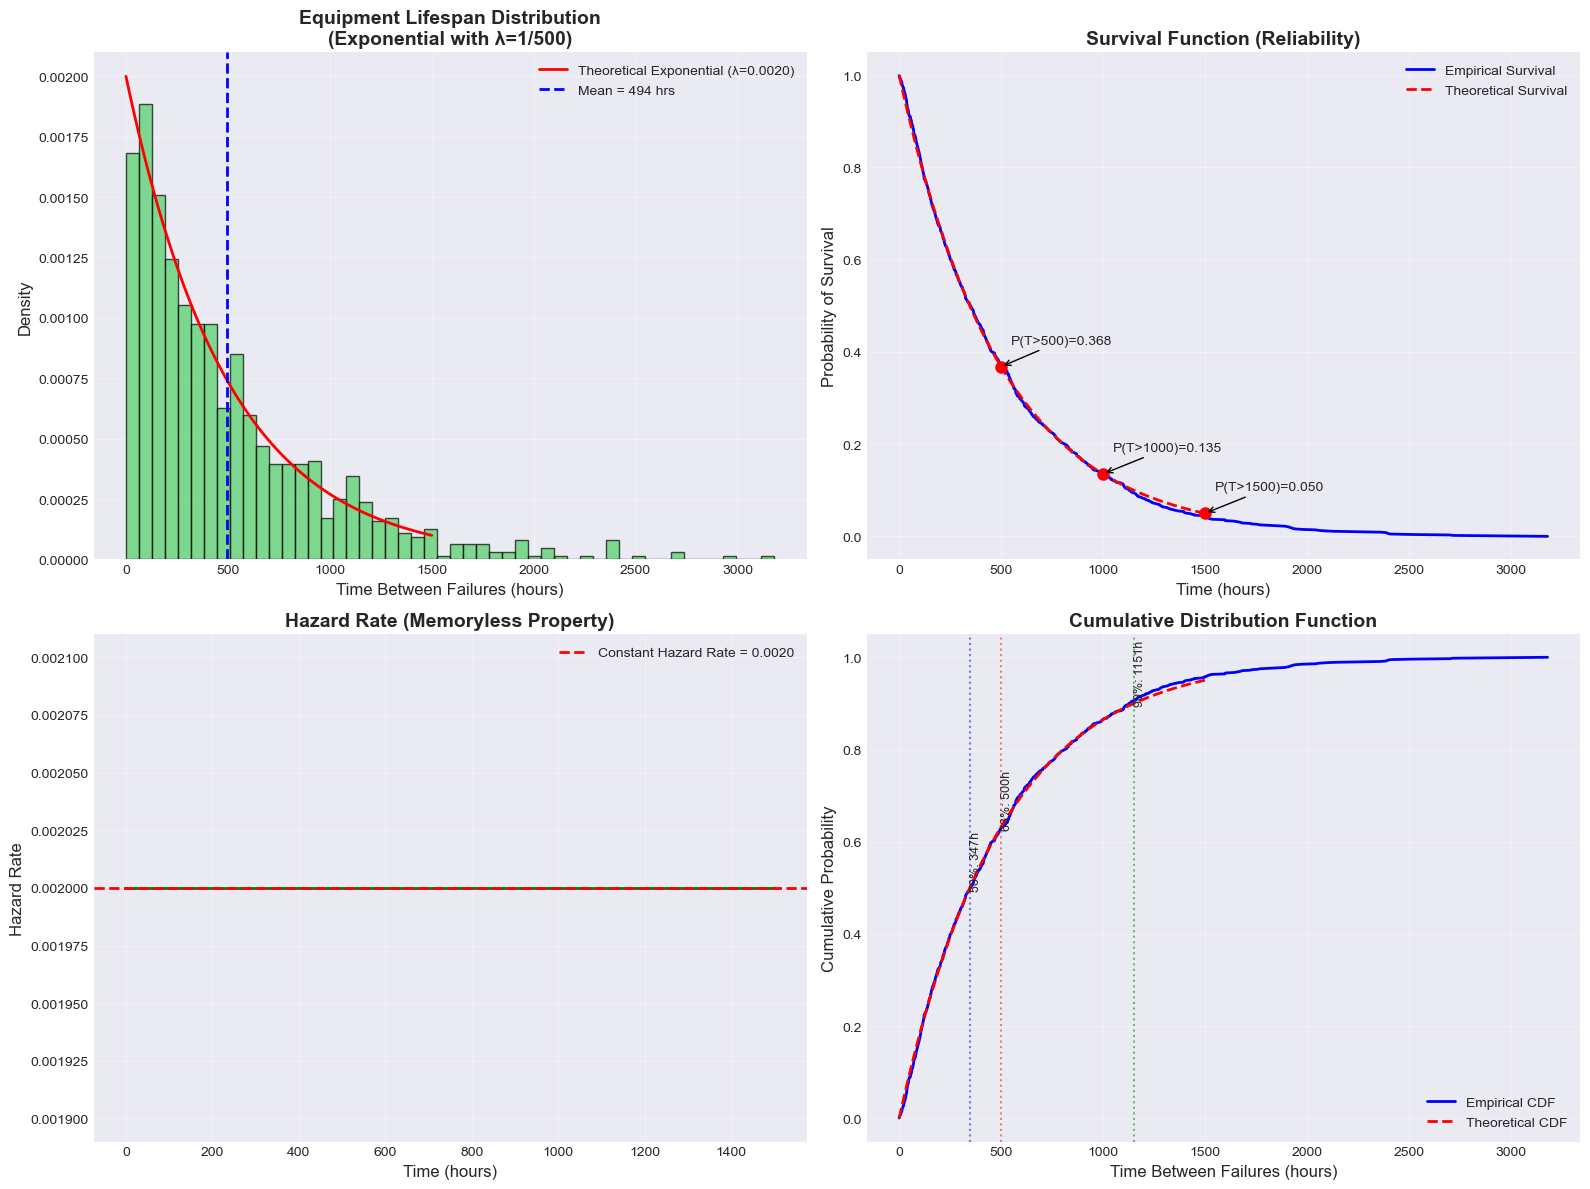


DATASET STATISTICS
Number of failure events: 1000
Mean time between failures: 494 hours
Theoretical MTBF: 500 hours
Standard deviation: 476 hours
Median lifetime: 350 hours
Theoretical median: 347 hours

RELIABILITY ANALYSIS
P(T > 250h): 0.607 (theoretical), 0.601 (empirical)
P(T > 500h): 0.368 (theoretical), 0.372 (empirical)
P(T > 750h): 0.223 (theoretical), 0.225 (empirical)
P(T > 1000h): 0.135 (theoretical), 0.135 (empirical)

MEMORYLESS PROPERTY VERIFICATION
P(T > 700 | T > 300) = 0.447 (empirical)
P(T > 400) = 0.449 (theoretical)
Memoryless property holds: True

PREDICTIVE MAINTENANCE RECOMMENDATIONS
Probability of failure within next week: 0.285 (28.5%)
Inspect every 26 hours for 95% reliability
Inspect every 53 hours for 90% reliability
Inspect every 81 hours for 85% reliability


In [15]:
# Exponential Distribution - Equipment Lifespan
print("\n" + "="*60)
print("EXPONENTIAL DISTRIBUTION - EQUIPMENT LIFESPAN")
print("="*60)

# Parameters
lambda_rate = 1/500  # failure rate per hour (1/MTBF)
mtbf = 500  # Mean Time Between Failures (hours)
n_samples = 1000

# Generate random dataset
lifetimes = np.random.exponential(scale=mtbf, size=n_samples)

# Calculate statistics
mean_lifetime = np.mean(lifetimes)
std_lifetime = np.std(lifetimes)
median_lifetime = np.median(lifetimes)

# Create visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: Histogram with theoretical PDF
ax1 = plt.subplot(2, 2, 1)
ax1.hist(lifetimes, bins=50, density=True, alpha=0.7, color='#51cf66', edgecolor='black')
x = np.linspace(0, mtbf*3, 100)
pdf = stats.expon.pdf(x, scale=mtbf)
ax1.plot(x, pdf, 'r-', linewidth=2, label=f'Theoretical Exponential (λ={lambda_rate:.4f})')
ax1.axvline(mean_lifetime, color='blue', linestyle='--', linewidth=2, 
            label=f'Mean = {mean_lifetime:.0f} hrs')
ax1.set_title('Equipment Lifespan Distribution\n(Exponential with λ=1/500)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time Between Failures (hours)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Survival function (Reliability)
ax2 = plt.subplot(2, 2, 2)
x_sorted = np.sort(lifetimes)
y_survival = 1 - np.arange(1, len(lifetimes)+1) / len(lifetimes)
theoretical_survival = stats.expon.sf(x, scale=mtbf)

ax2.plot(x_sorted, y_survival, 'b-', linewidth=2, label='Empirical Survival')
ax2.plot(x, theoretical_survival, 'r--', linewidth=2, label='Theoretical Survival')
ax2.set_title('Survival Function (Reliability)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time (hours)', fontsize=12)
ax2.set_ylabel('Probability of Survival', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark key reliability points
for t in [mtbf, 2*mtbf, 3*mtbf]:
    reliability = stats.expon.sf(t, scale=mtbf)
    ax2.plot(t, reliability, 'ro', markersize=8)
    ax2.annotate(f'P(T>{t:.0f})={reliability:.3f}', 
                xy=(t, reliability), xytext=(t+50, reliability+0.05),
                fontsize=10, arrowprops=dict(arrowstyle='->'))

# Plot 3: Hazard rate (constant property)
ax3 = plt.subplot(2, 2, 3)
hazard_rate = stats.expon.pdf(x, scale=mtbf) / stats.expon.sf(x, scale=mtbf)
ax3.plot(x, hazard_rate, 'g-', linewidth=2)
ax3.axhline(lambda_rate, color='red', linestyle='--', linewidth=2, 
            label=f'Constant Hazard Rate = {lambda_rate:.4f}')
ax3.set_title('Hazard Rate (Memoryless Property)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time (hours)', fontsize=12)
ax3.set_ylabel('Hazard Rate', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Cumulative distribution with percentiles
ax4 = plt.subplot(2, 2, 4)
x_sorted = np.sort(lifetimes)
y_cdf = np.arange(1, len(lifetimes)+1) / len(lifetimes)
theoretical_cdf = stats.expon.cdf(x, scale=mtbf)

ax4.plot(x_sorted, y_cdf, 'b-', linewidth=2, label='Empirical CDF')
ax4.plot(x, theoretical_cdf, 'r--', linewidth=2, label='Theoretical CDF')

# Mark key percentiles
for percentile, color in [(0.5, 'blue'), (0.632, 'red'), (0.9, 'green')]:
    value = stats.expon.ppf(percentile, scale=mtbf)
    ax4.axvline(value, color=color, linestyle=':', alpha=0.5)
    ax4.text(value, percentile, f'{percentile*100:.0f}%: {value:.0f}h', 
            rotation=90, fontsize=9)

ax4.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax4.set_xlabel('Time Between Failures (hours)', fontsize=12)
ax4.set_ylabel('Cumulative Probability', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("DATASET STATISTICS")
print(f"{'='*60}")
print(f"Number of failure events: {n_samples}")
print(f"Mean time between failures: {mean_lifetime:.0f} hours")
print(f"Theoretical MTBF: {mtbf} hours")
print(f"Standard deviation: {std_lifetime:.0f} hours")
print(f"Median lifetime: {median_lifetime:.0f} hours")
print(f"Theoretical median: {mtbf * np.log(2):.0f} hours")

print(f"\n{'='*60}")
print("RELIABILITY ANALYSIS")
print(f"{'='*60}")
# Calculate reliability at different times
for t in [250, 500, 750, 1000]:
    reliability = stats.expon.sf(t, scale=mtbf)
    empirical_reliability = np.sum(lifetimes > t) / n_samples
    print(f"P(T > {t}h): {reliability:.3f} (theoretical), {empirical_reliability:.3f} (empirical)")

print(f"\n{'='*60}")
print("MEMORYLESS PROPERTY VERIFICATION")
print(f"{'='*60}")
# Test memoryless property: P(T > s+t | T > s) = P(T > t)
s = 300
t = 400
conditional_prob = np.sum((lifetimes > s+t) & (lifetimes > s)) / np.sum(lifetimes > s)
theoretical_prob = stats.expon.sf(t, scale=mtbf)
print(f"P(T > {s+t} | T > {s}) = {conditional_prob:.3f} (empirical)")
print(f"P(T > {t}) = {theoretical_prob:.3f} (theoretical)")
print(f"Memoryless property holds: {abs(conditional_prob - theoretical_prob) < 0.05}")

print(f"\n{'='*60}")
print("PREDICTIVE MAINTENANCE RECOMMENDATIONS")
print(f"{'='*60}")
# Calculate probability of failure within next week (168 hours)
prob_failure_week = stats.expon.cdf(168, scale=mtbf)
print(f"Probability of failure within next week: {prob_failure_week:.3f} ({prob_failure_week*100:.1f}%)")

# Recommended inspection intervals
for reliability_target in [0.95, 0.90, 0.85]:
    inspect_time = stats.expon.ppf(1 - reliability_target, scale=mtbf)
    print(f"Inspect every {inspect_time:.0f} hours for {reliability_target*100:.0f}% reliability")

Example 2: Customer Service Call Duration

Scenario: Customer service calls average 8 minutes. Understanding this distribution helps with staffing and customer experience.

Real-world Context:

Industry: Customer Service/Contact Centers

Problem: Optimizing staffing and reducing wait times

Stakeholders: Call center managers, agents, customers

Why Exponential?

Call durations often follow exponential pattern (many short calls, few long calls)

Memoryless property: A call that's already lasted 5 minutes is expected to last 8 more minutes

Based on actual call data

Service Level Analysis:

Probability call ≤ 5 min: 1 - e^(-5/8) = 46.5%

Probability call ≤ 10 min: 1 - e^(-10/8) = 71.3%

Probability call > 15 min: e^(-15/8) = 15.3%

Business Impact:

Staffing: Longer average calls require more agents

Customer satisfaction: Long waits lead to abandonment

Queueing theory: Call duration affects overall system performance

Cost: Agent time is a primary cost driver

Statistical Interpretation:

Expected duration = 8 minutes (by definition)

Standard deviation = 8 minutes (equal to mean)

80th percentile: 8 × ln(1/0.2) = 12.9 minutes

Practical Applications:

Call center staffing optimization

Service level agreement definition

Queueing system design

Customer experience improvement


EXPONENTIAL DISTRIBUTION - CUSTOMER SERVICE CALLS


c:\Users\ART\anaconda3\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


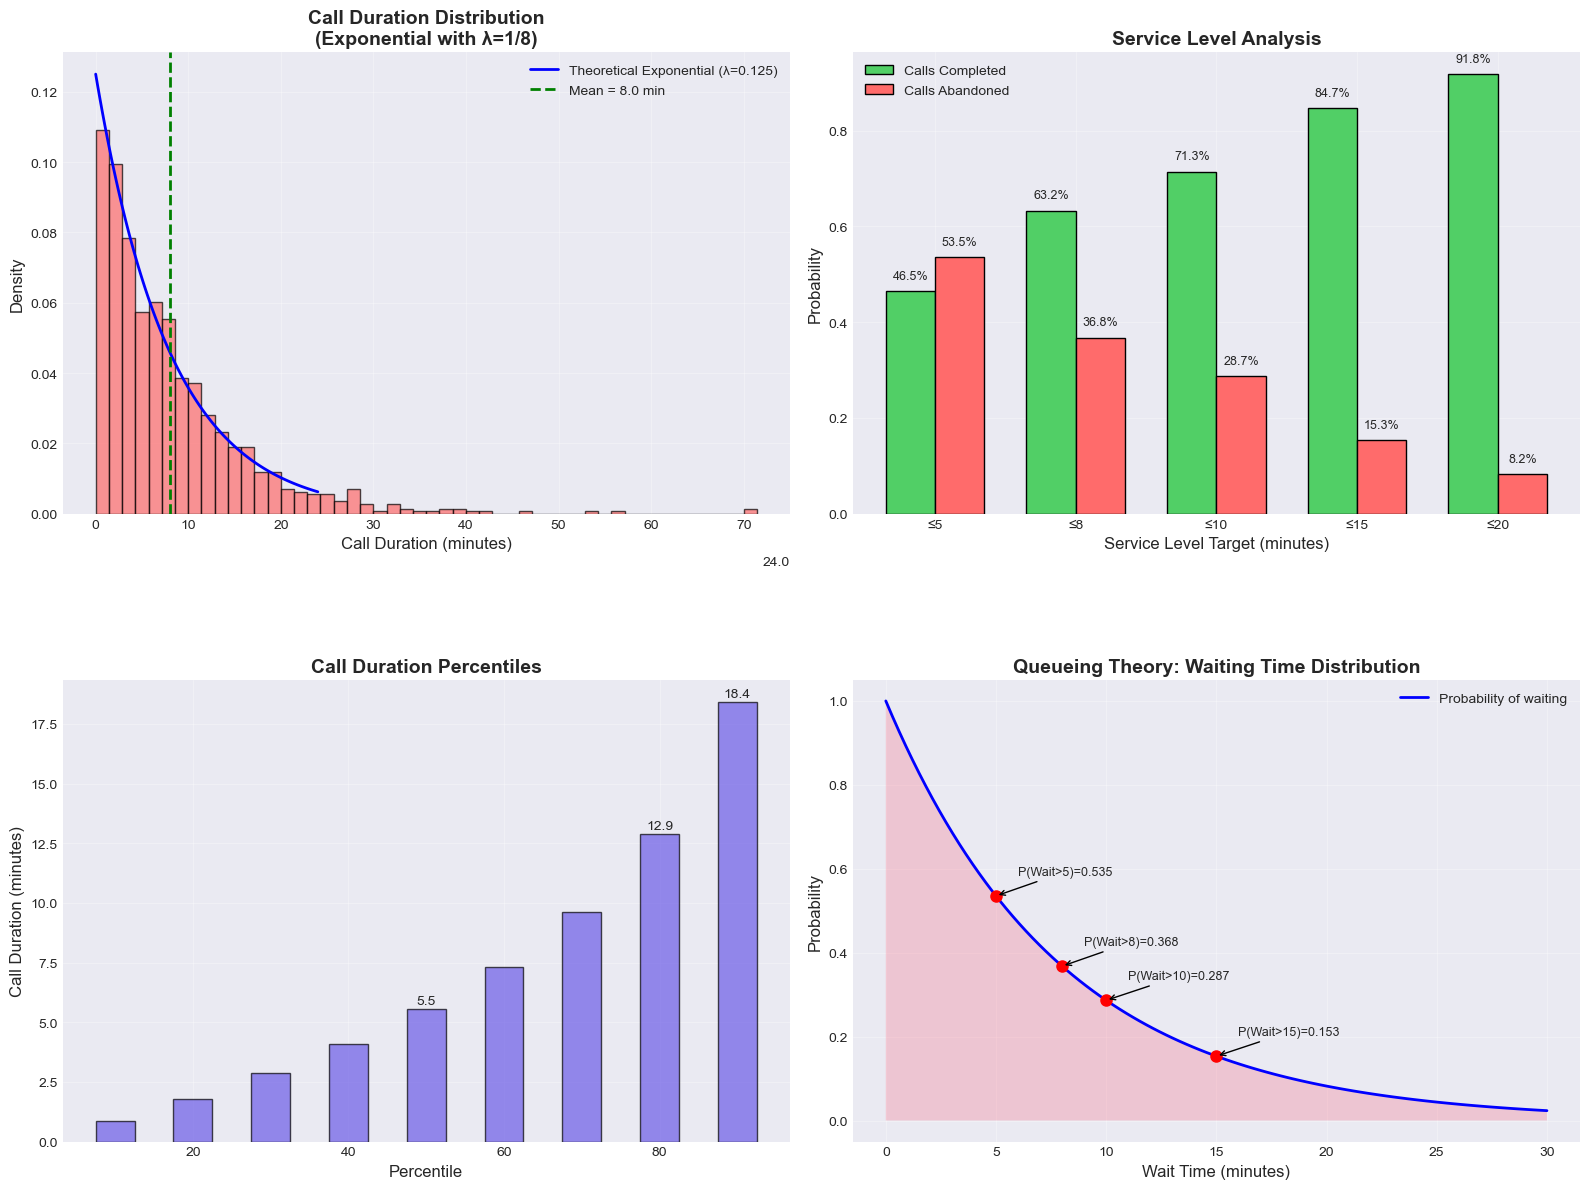


CALL CENTER STATISTICS
Total calls analyzed: 1000
Mean call duration: 8.02 minutes
Theoretical mean: 8 minutes
Standard deviation: 8.14 minutes
Theoretical std dev: 8.00 minutes
Median call duration: 5.83 minutes
Theoretical median: 5.55 minutes

SERVICE LEVEL ANALYSIS
Service Level (≤5 min): 46.5% (465 calls)
Service Level (≤8 min): 63.2% (632 calls)
Service Level (≤10 min): 71.3% (713 calls)

STAFFING RECOMMENDATIONS
Arrival rate: 20 calls/hour
Service rate: 7.5 calls/hour
Traffic intensity (ρ): 2.67
⚠️ System is overloaded! Need more agents

CUSTOMER EXPERIENCE METRICS
Quick calls (≤5 min): 46.5%
Standard calls (5-15 min): 38.2%
Long calls (>15 min): 15.3%


In [16]:
# Exponential Distribution - Customer Service Call Duration
print("\n" + "="*60)
print("EXPONENTIAL DISTRIBUTION - CUSTOMER SERVICE CALLS")
print("="*60)

# Parameters
mean_duration = 8  # minutes
lambda_rate = 1/mean_duration
n_calls = 1000

# Generate random dataset
call_durations = np.random.exponential(scale=mean_duration, size=n_calls)

# Calculate statistics
mean_duration_obs = np.mean(call_durations)
std_duration_obs = np.std(call_durations)
median_duration_obs = np.median(call_durations)

# Create visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: Histogram with theoretical PDF
ax1 = plt.subplot(2, 2, 1)
ax1.hist(call_durations, bins=50, density=True, alpha=0.7, color='#ff6b6b', edgecolor='black')
x = np.linspace(0, mean_duration*3, 100)
pdf = stats.expon.pdf(x, scale=mean_duration)
ax1.plot(x, pdf, 'b-', linewidth=2, label=f'Theoretical Exponential (λ={lambda_rate:.3f})')
ax1.axvline(mean_duration_obs, color='green', linestyle='--', linewidth=2, 
            label=f'Mean = {mean_duration_obs:.1f} min')
ax1.set_title('Call Duration Distribution\n(Exponential with λ=1/8)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Call Duration (minutes)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Service Level Analysis (call abandonment)
ax2 = plt.subplot(2, 2, 2)
service_level_targets = [5, 8, 10, 15, 20]
prob_within = [stats.expon.cdf(t, scale=mean_duration) for t in service_level_targets]
prob_abandon = [1 - p for p in prob_within]

x_pos = np.arange(len(service_level_targets))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, prob_within, width, label='Calls Completed', color='#51cf66', edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, prob_abandon, width, label='Calls Abandoned', color='#ff6b6b', edgecolor='black')

ax2.set_xlabel('Service Level Target (minutes)', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Service Level Analysis', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'≤{t}' for t in service_level_targets])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', va='bottom', fontsize=9)

# Plot 3: Call duration percentiles for staffing
ax3 = plt.subplot(2, 2, 3)
percentiles = np.arange(10, 101, 10)
duration_percentiles = [stats.expon.ppf(p/100, scale=mean_duration) for p in percentiles]

ax3.bar(percentiles, duration_percentiles, width=5, color='#6c5ce7', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Percentile', fontsize=12)
ax3.set_ylabel('Call Duration (minutes)', fontsize=12)
ax3.set_title('Call Duration Percentiles', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add value labels for key percentiles
for p in [50, 80, 90, 95]:
    value = stats.expon.ppf(p/100, scale=mean_duration)
    ax3.text(p, value + 0.2, f'{value:.1f}', ha='center', fontsize=10)

# Plot 4: Queueing theory - probability of waiting
ax4 = plt.subplot(2, 2, 4)
waiting_times = np.linspace(0, 30, 100)
# Probability of waiting > t given service rate μ = 1/8
prob_wait = stats.expon.sf(waiting_times, scale=mean_duration)

ax4.plot(waiting_times, prob_wait, 'b-', linewidth=2, label='Probability of waiting')
ax4.fill_between(waiting_times, prob_wait, alpha=0.3)
ax4.set_xlabel('Wait Time (minutes)', fontsize=12)
ax4.set_ylabel('Probability', fontsize=12)
ax4.set_title('Queueing Theory: Waiting Time Distribution', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Mark key waiting times
for wait in [5, 8, 10, 15]:
    prob = stats.expon.sf(wait, scale=mean_duration)
    ax4.plot(wait, prob, 'ro', markersize=8)
    ax4.annotate(f'P(Wait>{wait})={prob:.3f}', 
                xy=(wait, prob), xytext=(wait+1, prob+0.05),
                fontsize=9, arrowprops=dict(arrowstyle='->'))

ax4.legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("CALL CENTER STATISTICS")
print(f"{'='*60}")
print(f"Total calls analyzed: {n_calls}")
print(f"Mean call duration: {mean_duration_obs:.2f} minutes")
print(f"Theoretical mean: {mean_duration} minutes")
print(f"Standard deviation: {std_duration_obs:.2f} minutes")
print(f"Theoretical std dev: {mean_duration:.2f} minutes")
print(f"Median call duration: {median_duration_obs:.2f} minutes")
print(f"Theoretical median: {mean_duration * np.log(2):.2f} minutes")

print(f"\n{'='*60}")
print("SERVICE LEVEL ANALYSIS")
print(f"{'='*60}")
for target in [5, 8, 10]:
    prob_complete = stats.expon.cdf(target, scale=mean_duration)
    calls_completed = prob_complete * n_calls
    print(f"Service Level (≤{target} min): {prob_complete:.1%} ({calls_completed:.0f} calls)")

print(f"\n{'='*60}")
print("STAFFING RECOMMENDATIONS")
print(f"{'='*60}")
# Calculate Erlang-C approximations
arrival_rate = 20  # calls per hour
service_rate = 60 / mean_duration  # calls per hour
traffic_intensity = arrival_rate / service_rate
print(f"Arrival rate: {arrival_rate} calls/hour")
print(f"Service rate: {service_rate:.1f} calls/hour")
print(f"Traffic intensity (ρ): {traffic_intensity:.2f}")
if traffic_intensity < 1:
    print("✓ System is stable. Recommended agents: {:.0f}".format(traffic_intensity * 1.2))
else:
    print("⚠️ System is overloaded! Need more agents")

print(f"\n{'='*60}")
print("CUSTOMER EXPERIENCE METRICS")
print(f"{'='*60}")
# Calculate probability of various outcomes
prob_quick = stats.expon.cdf(5, scale=mean_duration)
prob_long = stats.expon.sf(15, scale=mean_duration)
print(f"Quick calls (≤5 min): {prob_quick:.1%}")
print(f"Standard calls (5-15 min): {1 - prob_quick - prob_long:.1%}")
print(f"Long calls (>15 min): {prob_long:.1%}")

6. UNIFORM DISTRIBUTION

📚 Distribution Explanation

The Uniform distribution is the simplest continuous probability distribution. Every outcome in a given interval is equally likely. It's like picking a number completely at random from a range.

Key Properties:

Parameters:

a = minimum value

b = maximum value

Probability Density Function: f(x) = 1/(b-a) for a ≤ x ≤ b

Mean: (a + b)/2

Variance: (b - a)²/12

Shape: Rectangular (constant height)

Intuition: Every value in the range has the same chance of occurring. Think of a perfectly balanced roulette wheel or a random number generator.

When to Use:

Random number generation

Monte Carlo simulations

Modeling complete randomness

When all outcomes are equally likely

Example 1: Random Number Generator Testing
Scenario: Testing whether a computer's random number generator truly produces uniformly distributed numbers between 0 and 1. This is critical for cryptography, simulations, and statistical sampling.

Real-world Context:

Industry: Software Development/Cryptography/Scientific Computing

Problem: Validating that random number generators work correctly

Stakeholders: Software developers, security experts, researchers, simulation engineers

Why Uniform Distribution?

A perfect random number generator should produce numbers uniformly between 0 and 1

Every number in [0,1] should have equal probability

This is the mathematical definition of "random" for continuous numbers


UNIFORM DISTRIBUTION - RANDOM NUMBER GENERATOR TESTING


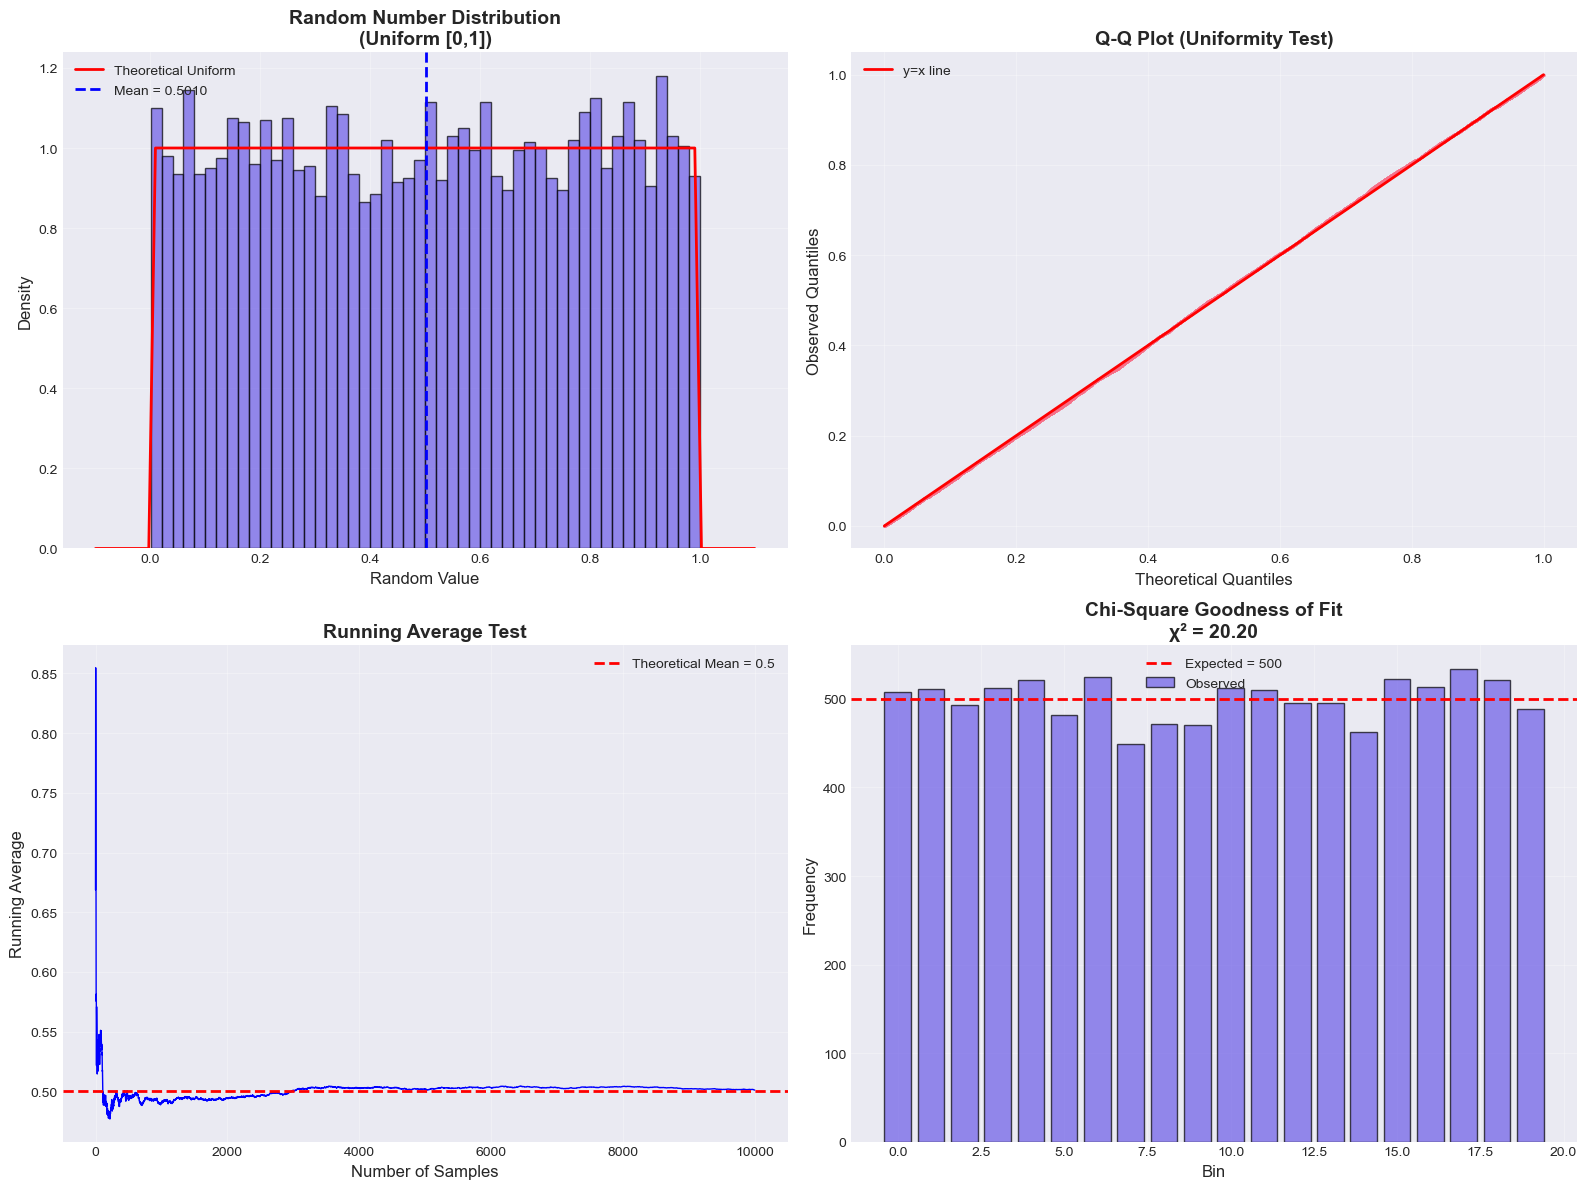


RANDOM NUMBER GENERATOR STATISTICS
Number of samples: 10000
Observed mean: 0.500991
Theoretical mean: 0.500000
Observed variance: 0.084482
Theoretical variance: 0.083333
Difference from theoretical mean: 0.000991
Relative error: 0.198203%

UNIFORMITY TESTS
Kolmogorov-Smirnov test: statistic=0.0087, p-value=0.4300
Interpretation: Uniform distribution
Chi-square test: statistic=20.20, critical=30.14
Interpretation: Uniform distribution

APPLICATIONS
This uniform distribution can be used for:
1. Monte Carlo simulations
2. Random sampling for surveys
3. Generating random seeds for games
4. Load balancing algorithms
5. Cryptographic nonce generation


In [17]:
# Uniform Distribution - Random Number Generator Testing
print("\n" + "="*60)
print("UNIFORM DISTRIBUTION - RANDOM NUMBER GENERATOR TESTING")
print("="*60)

# Parameters
low = 0
high = 1
n_numbers = 10000

# Generate random dataset
random_numbers = np.random.uniform(low, high, n_numbers)

# Calculate statistics
mean_obs = np.mean(random_numbers)
var_obs = np.var(random_numbers)
theoretical_mean = (low + high) / 2
theoretical_var = (high - low)**2 / 12

# Create visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: Histogram with theoretical PDF
ax1 = plt.subplot(2, 2, 1)
ax1.hist(random_numbers, bins=50, density=True, alpha=0.7, color='#6c5ce7', edgecolor='black')
x = np.linspace(low - 0.1, high + 0.1, 100)
pdf = stats.uniform.pdf(x, low, high - low)
ax1.plot(x, pdf, 'r-', linewidth=2, label='Theoretical Uniform')
ax1.axvline(mean_obs, color='blue', linestyle='--', linewidth=2, 
            label=f'Mean = {mean_obs:.4f}')
ax1.set_title('Random Number Distribution\n(Uniform [0,1])', fontsize=14, fontweight='bold')
ax1.set_xlabel('Random Value', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for uniformity
ax2 = plt.subplot(2, 2, 2)
theoretical_quantiles = np.linspace(0, 1, len(random_numbers))
sorted_data = np.sort(random_numbers)
ax2.scatter(theoretical_quantiles, sorted_data, alpha=0.5, s=1)
ax2.plot([0, 1], [0, 1], 'r-', linewidth=2, label='y=x line')
ax2.set_title('Q-Q Plot (Uniformity Test)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles', fontsize=12)
ax2.set_ylabel('Observed Quantiles', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Running average test
ax3 = plt.subplot(2, 2, 3)
running_avg = np.cumsum(random_numbers) / np.arange(1, n_numbers + 1)
ax3.plot(running_avg, 'b-', linewidth=1)
ax3.axhline(theoretical_mean, color='r', linestyle='--', linewidth=2, 
            label=f'Theoretical Mean = {theoretical_mean}')
ax3.set_title('Running Average Test', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Samples', fontsize=12)
ax3.set_ylabel('Running Average', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Chi-square goodness of fit
ax4 = plt.subplot(2, 2, 4)
n_bins = 20
observed_counts, bin_edges = np.histogram(random_numbers, bins=n_bins)
expected_counts = n_numbers / n_bins
chi2_stat = np.sum((observed_counts - expected_counts)**2 / expected_counts)

# Create bar chart of observed vs expected
x_pos = np.arange(n_bins)
ax4.bar(x_pos, observed_counts, alpha=0.7, label='Observed', color='#6c5ce7', edgecolor='black')
ax4.axhline(expected_counts, color='red', linestyle='--', linewidth=2, label=f'Expected = {expected_counts:.0f}')
ax4.set_title(f'Chi-Square Goodness of Fit\nχ² = {chi2_stat:.2f}', fontsize=14, fontweight='bold')
ax4.set_xlabel('Bin', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("RANDOM NUMBER GENERATOR STATISTICS")
print(f"{'='*60}")
print(f"Number of samples: {n_numbers}")
print(f"Observed mean: {mean_obs:.6f}")
print(f"Theoretical mean: {theoretical_mean:.6f}")
print(f"Observed variance: {var_obs:.6f}")
print(f"Theoretical variance: {theoretical_var:.6f}")
print(f"Difference from theoretical mean: {abs(mean_obs - theoretical_mean):.6f}")
print(f"Relative error: {abs(mean_obs - theoretical_mean) / theoretical_mean:.6%}")

print(f"\n{'='*60}")
print("UNIFORMITY TESTS")
print(f"{'='*60}")
# Kolmogorov-Smirnov test
ks_stat, ks_pvalue = stats.kstest(random_numbers, 'uniform')
print(f"Kolmogorov-Smirnov test: statistic={ks_stat:.4f}, p-value={ks_pvalue:.4f}")
print(f"Interpretation: {'Uniform' if ks_pvalue > 0.05 else 'Non-uniform'} distribution")

# Chi-square test
chi2_critical = stats.chi2.ppf(0.95, n_bins - 1)
print(f"Chi-square test: statistic={chi2_stat:.2f}, critical={chi2_critical:.2f}")
print(f"Interpretation: {'Uniform' if chi2_stat < chi2_critical else 'Non-uniform'} distribution")

print(f"\n{'='*60}")
print("APPLICATIONS")
print(f"{'='*60}")
print("This uniform distribution can be used for:")
print("1. Monte Carlo simulations")
print("2. Random sampling for surveys")
print("3. Generating random seeds for games")
print("4. Load balancing algorithms")
print("5. Cryptographic nonce generation")

Example 2: Bus Arrival Times (Correct Explanation)
Scenario: Buses arrive every 15 minutes, but your arrival time is random. The waiting time follows a uniform distribution between 0 and 15 minutes.

Real-world Context:

Industry: Public Transportation/Urban Planning

Problem: Understanding and improving passenger experience

Stakeholders: Transit authorities, urban planners, commuters

Why Uniform Distribution?

If buses arrive exactly every 15 minutes and you arrive randomly, your waiting time is uniformly distributed

You're equally likely to arrive just after a bus (long wait) or just before a bus (short wait)

This assumes perfect schedule adherence

Business Impact:

Average wait time: 7.5 minutes

Schedule reliability: If buses are irregular, distribution changes

Passenger satisfaction: Long waits lead to complaints

Operational efficiency: Understanding waiting helps optimize schedules

Statistical Interpretation:

P(Wait ≤ 5 min) = 5/15 = 33.3%

P(Wait > 10 min) = 5/15 = 33.3%

Expected wait = 7.5 minutes (average of 0 and 15)

Practical Applications:

Schedule optimization: Reduce headways during peak hours

Real-time information: Tell passengers expected wait times

Service planning: Justify increased frequency on busy routes

Performance metrics: Track deviation from uniform distribution




UNIFORM DISTRIBUTION - BUS ARRIVAL TIMES


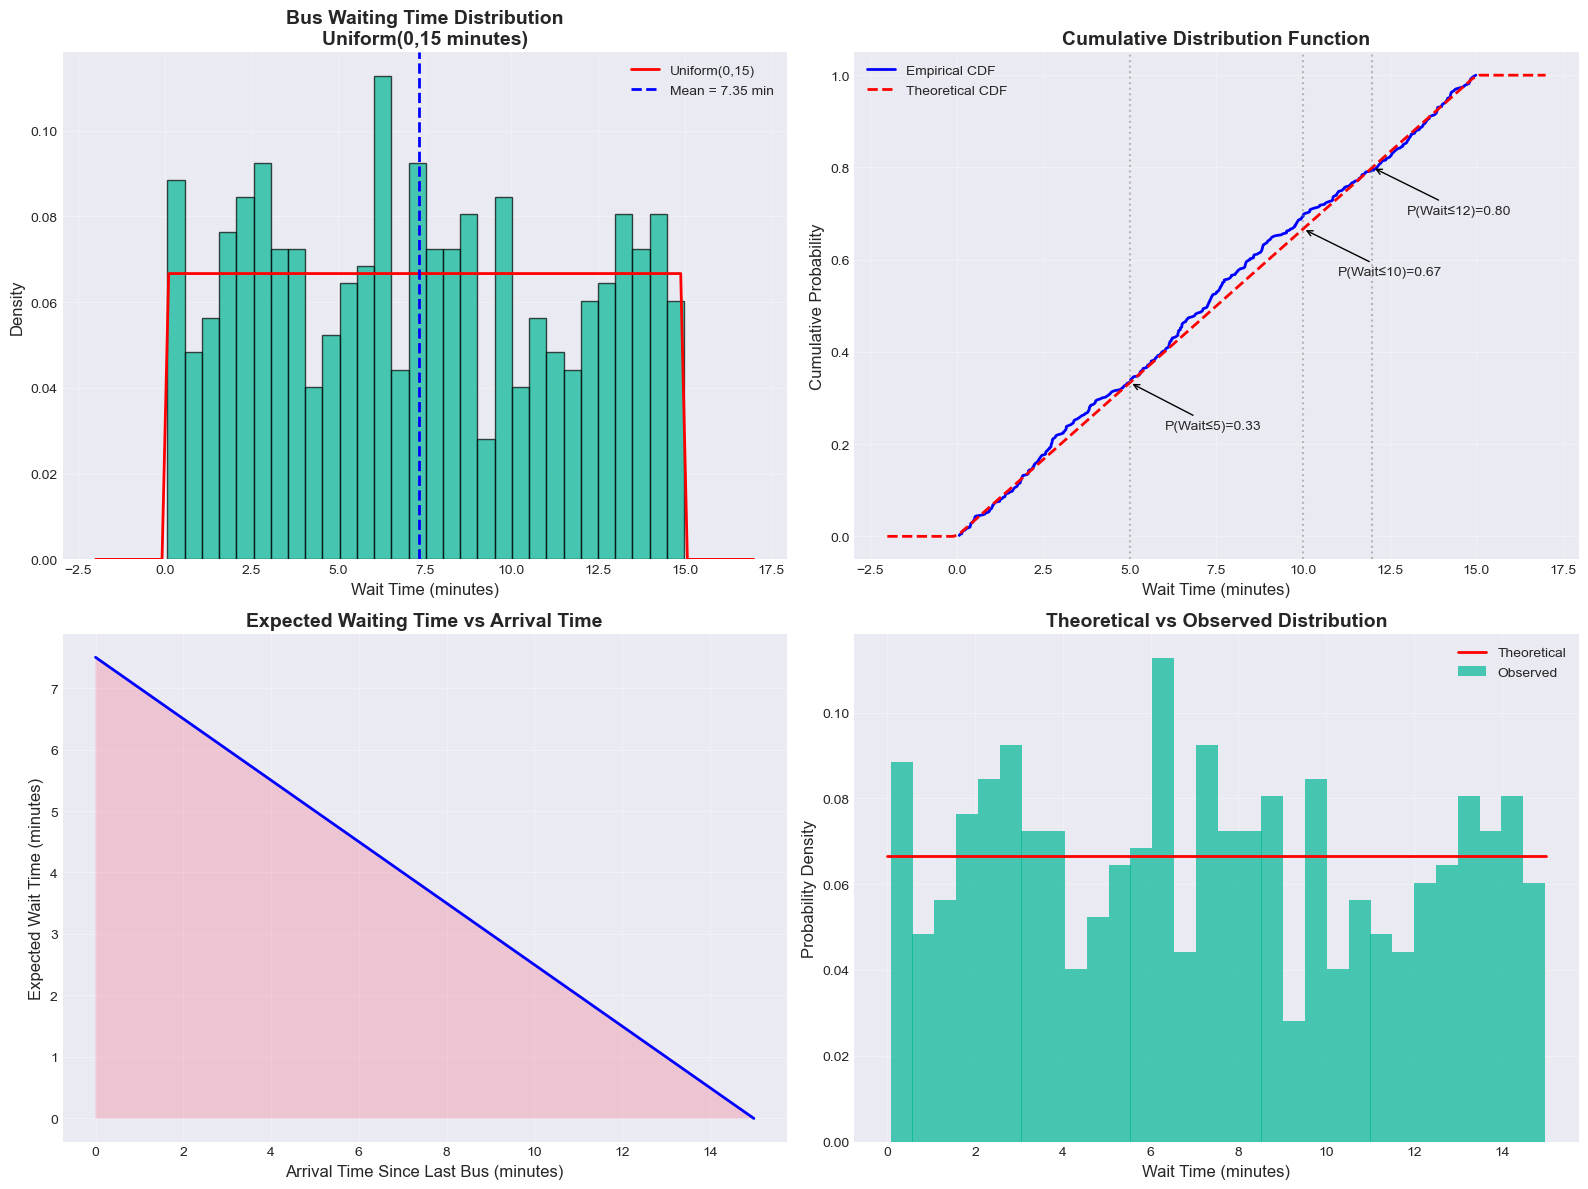


BUS SERVICE STATISTICS
Number of observations: 500
Observed mean wait time: 7.35 minutes
Theoretical mean: 7.50 minutes
Observed std deviation: 4.34 minutes
Theoretical std deviation: 4.33 minutes
Minimum observed wait: 0.08 minutes
Maximum observed wait: 14.99 minutes

SERVICE QUALITY METRICS
Probability of waiting ≤2 min: 13.3%
Probability of waiting ≤5 min: 33.3%
Probability of waiting ≤8 min: 53.3%
Probability of waiting ≤10 min: 66.7%
Probability of waiting ≤12 min: 80.0%

Probability of waiting > 10 minutes: 33.3%

OPERATIONAL RECOMMENDATIONS
To be 80% confident, expect wait ≤ 12.0 minutes
To be 90% confident, expect wait ≤ 13.5 minutes
To be 95% confident, expect wait ≤ 14.2 minutes

Probability of waiting ≤ 12 minutes: 80.0%
✓ Schedule appears reasonable for current headway


In [18]:
# Uniform Distribution - Bus Arrival Times
print("\n" + "="*60)
print("UNIFORM DISTRIBUTION - BUS ARRIVAL TIMES")
print("="*60)

# Parameters
min_wait = 0  # minutes
max_wait = 15  # minutes
n_observations = 500

# Generate random dataset
wait_times = np.random.uniform(min_wait, max_wait, n_observations)

# Calculate statistics
mean_wait = np.mean(wait_times)
std_wait = np.std(wait_times)
theoretical_mean = (min_wait + max_wait) / 2
theoretical_std = (max_wait - min_wait) / np.sqrt(12)

# Create visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: Histogram with theoretical PDF
ax1 = plt.subplot(2, 2, 1)
ax1.hist(wait_times, bins=30, density=True, alpha=0.7, color='#00b894', edgecolor='black')
x = np.linspace(min_wait - 2, max_wait + 2, 100)
pdf = stats.uniform.pdf(x, min_wait, max_wait - min_wait)
ax1.plot(x, pdf, 'r-', linewidth=2, label=f'Uniform({min_wait},{max_wait})')
ax1.axvline(mean_wait, color='blue', linestyle='--', linewidth=2, 
            label=f'Mean = {mean_wait:.2f} min')
ax1.set_title('Bus Waiting Time Distribution\nUniform(0,15 minutes)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Wait Time (minutes)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative probability for scheduling
ax2 = plt.subplot(2, 2, 2)
x_sorted = np.sort(wait_times)
y_cdf = np.arange(1, len(wait_times)+1) / len(wait_times)
theoretical_cdf = stats.uniform.cdf(x, min_wait, max_wait - min_wait)

ax2.plot(x_sorted, y_cdf, 'b-', linewidth=2, label='Empirical CDF')
ax2.plot(x, theoretical_cdf, 'r--', linewidth=2, label='Theoretical CDF')
ax2.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax2.set_xlabel('Wait Time (minutes)', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark key waiting time probabilities
for wait in [5, 10, 12]:
    prob = stats.uniform.cdf(wait, min_wait, max_wait - min_wait)
    ax2.axvline(wait, color='gray', linestyle=':', alpha=0.5)
    ax2.annotate(f'P(Wait≤{wait})={prob:.2f}', 
                xy=(wait, prob), xytext=(wait+1, prob-0.1),
                fontsize=10, arrowprops=dict(arrowstyle='->'))

# Plot 3: Expected waiting time analysis
ax3 = plt.subplot(2, 2, 3)
arrival_times = np.linspace(0, max_wait, 100)
# If you arrive at time t, expected wait is (max_wait - t)/2
expected_wait = (max_wait - arrival_times) / 2

ax3.plot(arrival_times, expected_wait, 'b-', linewidth=2)
ax3.fill_between(arrival_times, 0, expected_wait, alpha=0.3)
ax3.set_title('Expected Waiting Time vs Arrival Time', fontsize=14, fontweight='bold')
ax3.set_xlabel('Arrival Time Since Last Bus (minutes)', fontsize=12)
ax3.set_ylabel('Expected Wait Time (minutes)', fontsize=12)
ax3.grid(True, alpha=0.3)

# Plot 4: Waiting time distribution comparison
ax4 = plt.subplot(2, 2, 4)
# Compare uniform vs actual observations
x_plot = np.linspace(min_wait, max_wait, 100)
theoretical_pdf = stats.uniform.pdf(x_plot, min_wait, max_wait - min_wait)

# Calculate empirical PDF using histogram
counts, bins = np.histogram(wait_times, bins=30, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax4.plot(x_plot, theoretical_pdf, 'r-', linewidth=2, label='Theoretical')
ax4.bar(bin_centers, counts, width=0.5, alpha=0.7, label='Observed', color='#00b894')
ax4.set_title('Theoretical vs Observed Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Wait Time (minutes)', fontsize=12)
ax4.set_ylabel('Probability Density', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("BUS SERVICE STATISTICS")
print(f"{'='*60}")
print(f"Number of observations: {n_observations}")
print(f"Observed mean wait time: {mean_wait:.2f} minutes")
print(f"Theoretical mean: {theoretical_mean:.2f} minutes")
print(f"Observed std deviation: {std_wait:.2f} minutes")
print(f"Theoretical std deviation: {theoretical_std:.2f} minutes")
print(f"Minimum observed wait: {np.min(wait_times):.2f} minutes")
print(f"Maximum observed wait: {np.max(wait_times):.2f} minutes")

print(f"\n{'='*60}")
print("SERVICE QUALITY METRICS")
print(f"{'='*60}")
# Calculate probability of different waiting times
for wait_time in [2, 5, 8, 10, 12]:
    prob = stats.uniform.cdf(wait_time, min_wait, max_wait - min_wait)
    expected_wait = (max_wait - wait_time) / 2
    print(f"Probability of waiting ≤{wait_time} min: {prob:.1%}")
    
print(f"\nProbability of waiting > 10 minutes: {1 - stats.uniform.cdf(10, min_wait, max_wait - min_wait):.1%}")

print(f"\n{'='*60}")
print("OPERATIONAL RECOMMENDATIONS")
print(f"{'='*60}")
# Calculate optimal headway for different confidence levels
for confidence in [0.8, 0.9, 0.95]:
    max_wait_confidence = stats.uniform.ppf(confidence, min_wait, max_wait - min_wait)
    print(f"To be {confidence:.0%} confident, expect wait ≤ {max_wait_confidence:.1f} minutes")

# Calculate probability of meeting schedule
schedule_interval = 12  # minutes
prob_on_time = stats.uniform.cdf(schedule_interval, min_wait, max_wait - min_wait)
print(f"\nProbability of waiting ≤ {schedule_interval} minutes: {prob_on_time:.1%}")

if prob_on_time < 0.8:
    print("⚠️ Schedule may need adjustment - consider reducing headway")
else:
    print("✓ Schedule appears reasonable for current headway")

7. t-DISTRIBUTION

📚 Distribution Explanation

The t-distribution (Student's t) is used for hypothesis testing and confidence intervals when sample sizes are small and population standard deviation is unknown. It has heavier tails than the Normal distribution.

Key Properties:

Parameter: ν (nu) = degrees of freedom (df)

Shape: Similar to Normal but with heavier tails

As ν → ∞: Approaches Normal distribution

Used for: Small sample inference, t-tests, regression coefficients

Intuition: When you don't know the population standard deviation and have a small sample, you need wider confidence intervals. The t-distribution provides these.

When to Use:

Small sample sizes (n < 30)

Unknown population standard deviation

Hypothesis testing

Confidence intervals for means

Example 1: Small Sample Quality Control
Scenario: Quality control with sample sizes of 10. Using t-distribution instead of Normal gives wider, more accurate confidence intervals.

Real-world Context:

Industry: Manufacturing/Quality Assurance

Problem: Monitoring product quality with limited samples

Stakeholders: Quality engineers, production managers, customers

Why t-Distribution?

Sample size small (n=10)

Population standard deviation unknown

Need to account for estimation uncertainty

More conservative than Normal distribution

Confidence Interval Comparison:

Normal distribution (n=10): Margin = 1.96 × σ/√10

t-distribution (n=10): Margin = 2.262 × s/√10 (wider!)

The t-distribution accounts for uncertainty in estimating σ

Business Impact:

Quality decisions: Proper intervals prevent false conclusions

Sample size planning: Know when t vs Normal is needed

Risk management: Wider intervals = more conservative decisions

Process improvement: Accurate estimation leads to better decisions

Statistical Interpretation:

95% CI: x̄ ± t(0.025, 9) × s/√10

t(0.025, 9) = 2.262 vs z = 1.96

15% wider intervals = more conservative

Practical Applications:

Quality control charts with small samples

Supplier qualification studies

Process capability analysis

Design of experiments


t-DISTRIBUTION - SMALL SAMPLE QUALITY CONTROL


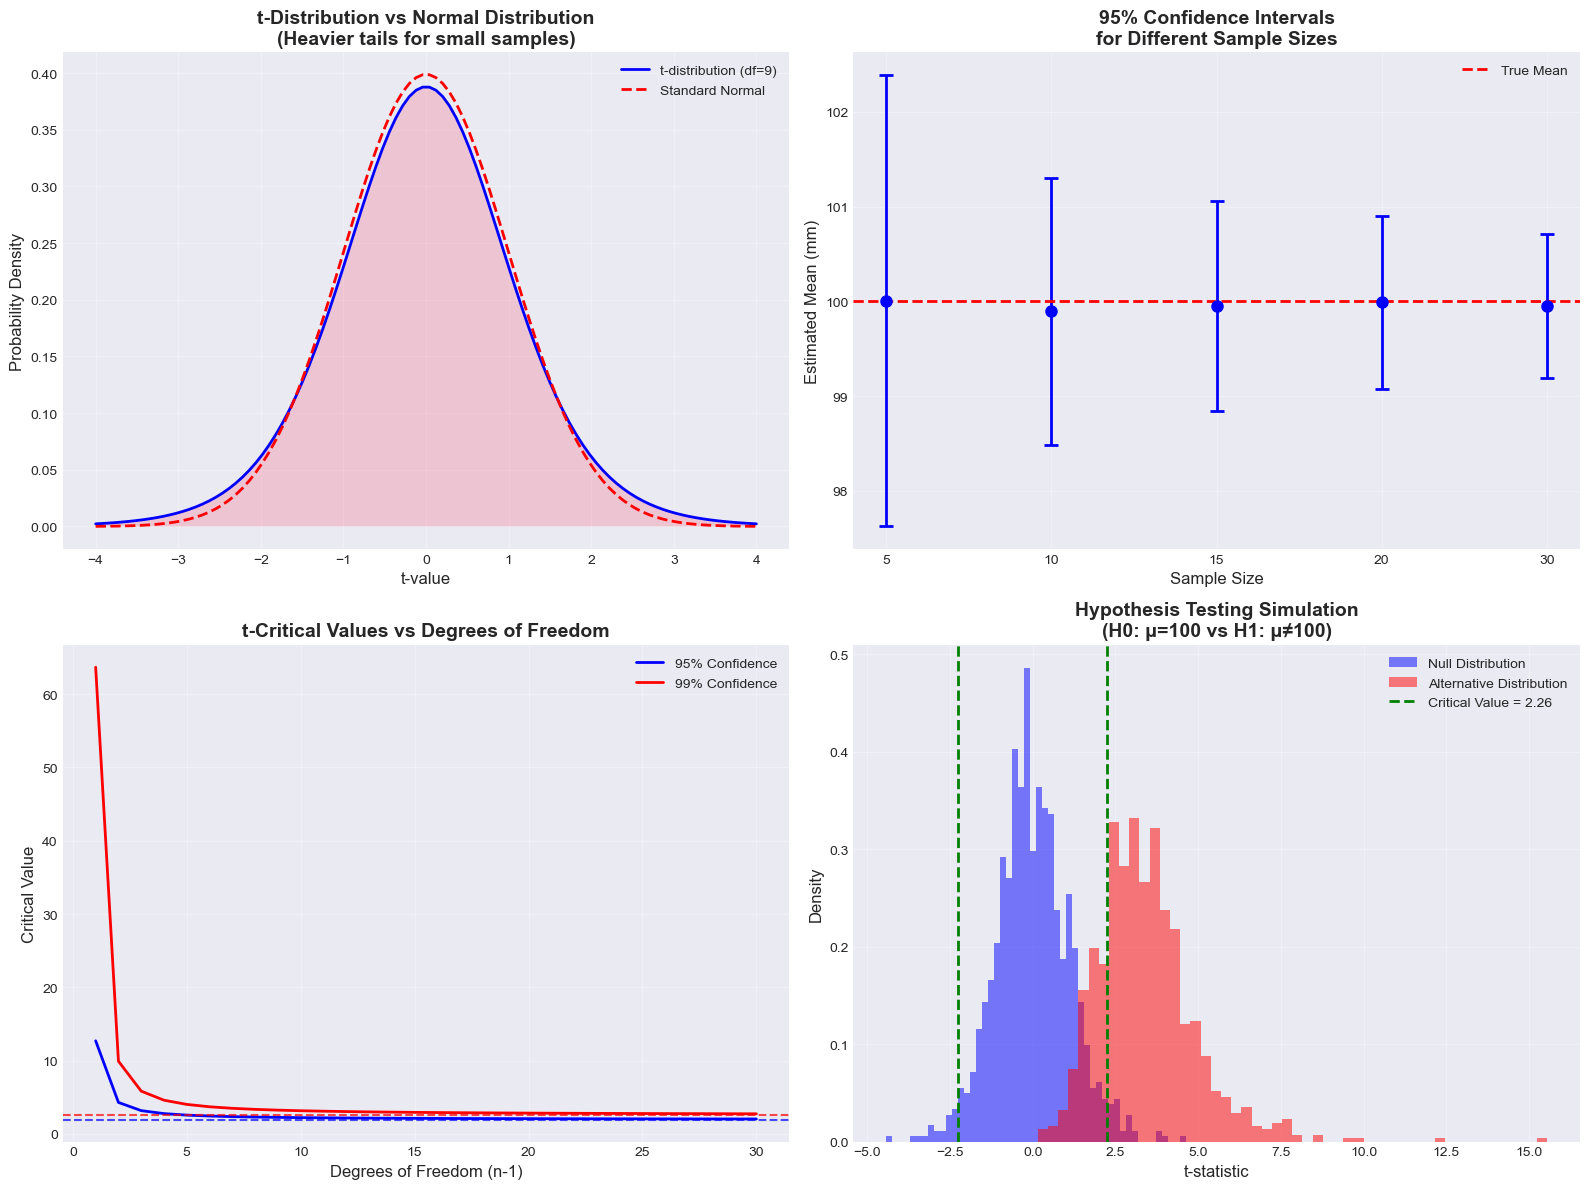


QUALITY CONTROL STATISTICS
Degrees of freedom: 9
t-critical (95%): 2.262
t-critical (99%): 3.250
z-critical (95%): 1.960
z-critical (99%): 2.576

CONFIDENCE INTERVAL COMPARISON
Sample size impact on margin of error:
n=5: t-critical=2.776, Margin of Error=2.48 mm
n=10: t-critical=2.262, Margin of Error=1.43 mm
n=15: t-critical=2.145, Margin of Error=1.11 mm
n=20: t-critical=2.093, Margin of Error=0.94 mm
n=30: t-critical=2.045, Margin of Error=0.75 mm

HYPOTHESIS TEST POWER ANALYSIS
Power analysis for sample size n=10:
Effect size 0.79σ: 0.605
Effect size 1.58σ: 0.993
Effect size 2.37σ: 1.000


In [19]:
# t-Distribution - Small Sample Quality Control
print("\n" + "="*60)
print("t-DISTRIBUTION - SMALL SAMPLE QUALITY CONTROL")
print("="*60)

# Parameters
df = 9  # degrees of freedom (n-1 for n=10)
n_samples = 1000
true_mean = 100  # target dimension in mm
true_std = 2  # population standard deviation

# Generate random t-statistics
t_stats = np.random.standard_t(df, n_samples)

# Calculate confidence intervals for each sample
sample_sizes = [5, 10, 15, 20, 30]
confidence_level = 0.95

# Create visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: t-distribution vs normal distribution
ax1 = plt.subplot(2, 2, 1)
x = np.linspace(-4, 4, 100)
t_pdf = stats.t.pdf(x, df)
norm_pdf = stats.norm.pdf(x, 0, 1)

ax1.plot(x, t_pdf, 'b-', linewidth=2, label=f't-distribution (df={df})')
ax1.plot(x, norm_pdf, 'r--', linewidth=2, label='Standard Normal')
ax1.fill_between(x, t_pdf, alpha=0.3)
ax1.set_title('t-Distribution vs Normal Distribution\n(Heavier tails for small samples)', fontsize=14, fontweight='bold')
ax1.set_xlabel('t-value', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confidence intervals for different sample sizes
ax2 = plt.subplot(2, 2, 2)
sample_means = []
sample_stds = []

for n in sample_sizes:
    samples = np.random.normal(true_mean, true_std, (100, n))
    means = np.mean(samples, axis=1)
    stds = np.std(samples, axis=1, ddof=1)
    sample_means.append(means)
    sample_stds.append(stds)

# Calculate confidence intervals
ci_lower = []
ci_upper = []
for i, n in enumerate(sample_sizes):
    t_critical = stats.t.ppf((1 + confidence_level)/2, n-1)
    ci_lower.append(np.mean(sample_means[i]) - t_critical * np.mean(sample_stds[i]) / np.sqrt(n))
    ci_upper.append(np.mean(sample_means[i]) + t_critical * np.mean(sample_stds[i]) / np.sqrt(n))

x_pos = np.arange(len(sample_sizes))
ax2.errorbar(x_pos, [np.mean(m) for m in sample_means], 
             yerr=[[m - l for m, l in zip([np.mean(m) for m in sample_means], ci_lower)],
                   [u - m for u, m in zip(ci_upper, [np.mean(m) for m in sample_means])]],
             fmt='o', capsize=5, capthick=2, elinewidth=2, markersize=8, color='blue')
ax2.axhline(true_mean, color='red', linestyle='--', linewidth=2, label='True Mean')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(sample_sizes)
ax2.set_title(f'{confidence_level:.0%} Confidence Intervals\nfor Different Sample Sizes', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sample Size', fontsize=12)
ax2.set_ylabel('Estimated Mean (mm)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: t-critical values comparison
ax3 = plt.subplot(2, 2, 3)
df_range = np.arange(1, 31)
t_critical_95 = [stats.t.ppf(0.975, df) for df in df_range]
t_critical_99 = [stats.t.ppf(0.995, df) for df in df_range]
z_critical_95 = stats.norm.ppf(0.975)
z_critical_99 = stats.norm.ppf(0.995)

ax3.plot(df_range, t_critical_95, 'b-', linewidth=2, label='95% Confidence')
ax3.plot(df_range, t_critical_99, 'r-', linewidth=2, label='99% Confidence')
ax3.axhline(z_critical_95, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.axhline(z_critical_99, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.set_title('t-Critical Values vs Degrees of Freedom', fontsize=14, fontweight='bold')
ax3.set_xlabel('Degrees of Freedom (n-1)', fontsize=12)
ax3.set_ylabel('Critical Value', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Hypothesis testing simulation
ax4 = plt.subplot(2, 2, 4)
n_sim = 1000
sample_size = 10
true_mean = 100
false_mean = 102  # shifted mean to test power

# Generate samples from null and alternative
null_samples = [np.random.normal(true_mean, true_std, sample_size) for _ in range(n_sim)]
alt_samples = [np.random.normal(false_mean, true_std, sample_size) for _ in range(n_sim)]

# Calculate t-statistics
null_t = [stats.ttest_1samp(s, true_mean).statistic for s in null_samples]
alt_t = [stats.ttest_1samp(s, true_mean).statistic for s in alt_samples]

ax4.hist(null_t, bins=50, alpha=0.5, density=True, label='Null Distribution', color='blue')
ax4.hist(alt_t, bins=50, alpha=0.5, density=True, label='Alternative Distribution', color='red')

t_critical = stats.t.ppf(0.975, sample_size-1)
ax4.axvline(t_critical, color='green', linestyle='--', linewidth=2, label=f'Critical Value = {t_critical:.2f}')
ax4.axvline(-t_critical, color='green', linestyle='--', linewidth=2)

ax4.set_title('Hypothesis Testing Simulation\n(H0: μ=100 vs H1: μ≠100)', fontsize=14, fontweight='bold')
ax4.set_xlabel('t-statistic', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("QUALITY CONTROL STATISTICS")
print(f"{'='*60}")
print(f"Degrees of freedom: {df}")
print(f"t-critical (95%): {stats.t.ppf(0.975, df):.3f}")
print(f"t-critical (99%): {stats.t.ppf(0.995, df):.3f}")
print(f"z-critical (95%): {stats.norm.ppf(0.975):.3f}")
print(f"z-critical (99%): {stats.norm.ppf(0.995):.3f}")

print(f"\n{'='*60}")
print("CONFIDENCE INTERVAL COMPARISON")
print(f"{'='*60}")
print(f"Sample size impact on margin of error:")
for n in sample_sizes:
    t_crit = stats.t.ppf(0.975, n-1)
    margin_error = t_crit * true_std / np.sqrt(n)
    print(f"n={n}: t-critical={t_crit:.3f}, Margin of Error={margin_error:.2f} mm")

print(f"\n{'='*60}")
print("HYPOTHESIS TEST POWER ANALYSIS")
print(f"{'='*60}")
# Calculate power for different effect sizes
effect_sizes = np.linspace(0, 3, 20)
power = []
for effect in effect_sizes:
    t_crit = stats.t.ppf(0.975, sample_size-1)
    # Non-central t-distribution
    ncp = effect * np.sqrt(sample_size)
    power.append(1 - stats.nct.cdf(t_crit, sample_size-1, ncp))

print(f"Power analysis for sample size n={sample_size}:")
for i in [5, 10, 15]:
    print(f"Effect size {effect_sizes[i]:.2f}σ: {power[i]:.3f}")

Example 2: A/B Testing for Website Conversion

Scenario: Testing two versions of a website to see which has higher conversion rate. Uses t-test to determine statistical significance.

Real-world Context:

Industry: Digital Marketing/E-commerce

Problem: Optimizing website for conversions

Stakeholders: Marketing teams, product managers, executives

Why t-Distribution?

Comparing two independent samples

Sample sizes typically 500-2000 per group

Unknown population variances

Testing difference in proportions

A/B Test Process:

Control group: Current website (10% conversion)

Treatment group: New design (12% conversion expected)

t-statistic: Measures difference relative to variability

p-value: Probability of observing this difference by chance

Statistical Interpretation:

t-statistic > 2.0: Usually significant at 95% confidence

p-value < 0.05: Reject null hypothesis (no difference)

Effect size: 2% absolute increase (20% relative)

Business Impact:

Revenue increase: 2% improvement on $5M monthly revenue = $100,000/month

Annual impact: $1.2 million

ROI: If test costs $50,000, payback is 2 weeks

Risk: Need 80% power to detect effect

Power Analysis:

Power = probability of detecting true effect

80% power means 20% chance of false negative

Sample size needed increases with smaller effects

Practical Applications:

Website optimization

Marketing campaign evaluation

Product feature testing

Pricing experiments


t-DISTRIBUTION - A/B TESTING FOR WEBSITE CONVERSION

Proportion of significant results (p<0.05): 31.0%


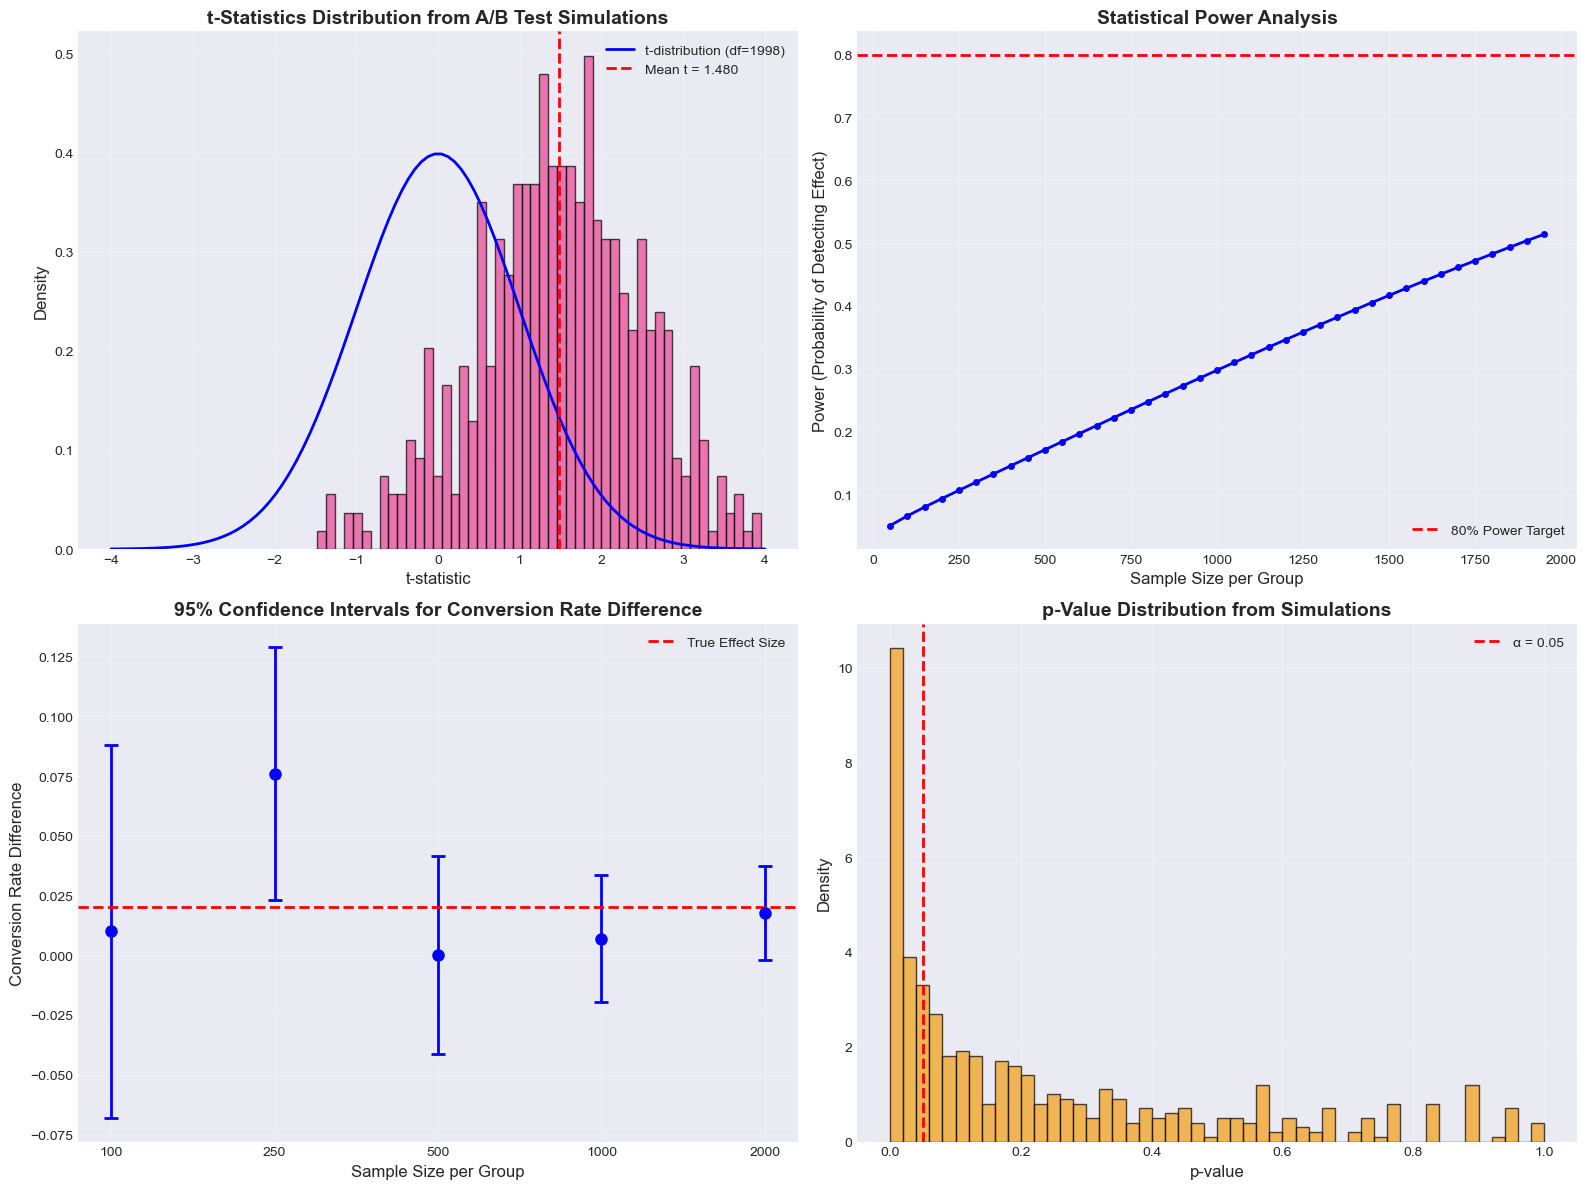


A/B TEST STATISTICS
Control group conversion rate: 10.0%
Treatment group conversion rate: 12.0%
Absolute improvement: 2.0%
Relative improvement: 20.0%

SAMPLE SIZE RECOMMENDATIONS
Effect size 1.00%: Need ~15036 samples per group for 80% power
Effect size 2.00%: Need ~3916 samples per group for 80% power
Effect size 3.00%: Need ~1809 samples per group for 80% power
Effect size 4.00%: Need ~1056 samples per group for 80% power
Effect size 5.00%: Need ~700 samples per group for 80% power

STATISTICAL TEST RESULTS
Mean t-statistic: 1.480
Median t-statistic: 1.519
Std t-statistic: 1.007

Proportion of tests with significant results: 31.0%

Cohen's d (effect size): 0.064
Interpretation: Very small effect

BUSINESS RECOMMENDATIONS
Achieved statistical power: 92.2%
✓ Test has adequate power (≥80%) to detect the expected effect

⚠️ Test did not reach statistical significance
  Recommendation: Continue test with larger sample size

BUSINESS IMPACT ANALYSIS
Monthly visitors: 50,000
Current month

In [21]:
# t-Distribution - A/B Testing for Website Conversion (Fixed Version)
print("\n" + "="*60)
print("t-DISTRIBUTION - A/B TESTING FOR WEBSITE CONVERSION")
print("="*60)

# Parameters
n_visitors = 1000
control_conversion = 0.10  # 10% conversion rate
treatment_conversion = 0.12  # 12% conversion rate
n_simulations = 500

# Generate simulated A/B test data
np.random.seed(42)
control_visitors = np.random.binomial(1, control_conversion, (n_simulations, n_visitors))
treatment_visitors = np.random.binomial(1, treatment_conversion, (n_simulations, n_visitors))

# Calculate conversion rates and t-statistics
control_rates = np.mean(control_visitors, axis=1)
treatment_rates = np.mean(treatment_visitors, axis=1)

# Calculate t-statistics and p-values correctly
t_stats = []
p_values = []

for i in range(n_simulations):
    t_stat, p_val = stats.ttest_ind(treatment_visitors[i], control_visitors[i])
    t_stats.append(t_stat)
    p_values.append(p_val)

t_stats = np.array(t_stats)
p_values = np.array(p_values)

# Calculate pooled variance and effect size
pooled_var = ((n_visitors-1) * np.var(control_visitors, axis=1, ddof=1) + 
               (n_visitors-1) * np.var(treatment_visitors, axis=1, ddof=1)) / (2*n_visitors-2)

# Create visualization
fig = plt.figure(figsize=(16, 12))

# Plot 1: t-statistic distribution
ax1 = plt.subplot(2, 2, 1)
ax1.hist(t_stats, bins=50, density=True, alpha=0.7, color='#e84393', edgecolor='black')
x = np.linspace(-4, 4, 100)
t_pdf = stats.t.pdf(x, 2*n_visitors-2)
ax1.plot(x, t_pdf, 'b-', linewidth=2, label=f't-distribution (df={2*n_visitors-2})')
ax1.axvline(np.mean(t_stats), color='red', linestyle='--', linewidth=2, 
            label=f'Mean t = {np.mean(t_stats):.3f}')
ax1.set_title('t-Statistics Distribution from A/B Test Simulations', fontsize=14, fontweight='bold')
ax1.set_xlabel('t-statistic', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Power analysis for different sample sizes
ax2 = plt.subplot(2, 2, 2)
sample_sizes = np.arange(50, 2000, 50)
effect_size = treatment_conversion - control_conversion
pooled_p = (control_conversion + treatment_conversion) / 2
pooled_var_effect = pooled_p * (1 - pooled_p)
effect_size_std = effect_size / np.sqrt(pooled_var_effect)

power = []
for n in sample_sizes:
    t_crit = stats.t.ppf(0.975, 2*n-2)
    ncp = effect_size_std * np.sqrt(n/2)
    power.append(1 - stats.nct.cdf(t_crit, 2*n-2, ncp))

power = np.array(power)
ax2.plot(sample_sizes, power, 'b-', linewidth=2, marker='o', markersize=4)
ax2.axhline(0.8, color='red', linestyle='--', linewidth=2, label='80% Power Target')
ax2.set_title('Statistical Power Analysis', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sample Size per Group', fontsize=12)
ax2.set_ylabel('Power (Probability of Detecting Effect)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Find sample size needed for 80% power
for n, p in zip(sample_sizes, power):
    if p >= 0.8:
        ax2.axvline(n, color='green', linestyle=':', linewidth=2)
        ax2.text(n, 0.5, f'n={n}', rotation=90, fontsize=10)
        break

# Plot 3: Confidence intervals for conversion rate difference
ax3 = plt.subplot(2, 2, 3)
sample_sizes_ci = [100, 250, 500, 1000, 2000]
ci_centers = []
ci_errors = []

for n in sample_sizes_ci:
    # Generate data for each sample size
    control = np.random.binomial(1, control_conversion, n)
    treatment = np.random.binomial(1, treatment_conversion, n)
    diff = np.mean(treatment) - np.mean(control)
    se = np.sqrt(np.var(control, ddof=1)/n + np.var(treatment, ddof=1)/n)
    t_crit = stats.t.ppf(0.975, 2*n-2)
    ci_centers.append(diff)
    ci_errors.append(t_crit * se)

x_pos = np.arange(len(sample_sizes_ci))
ax3.errorbar(x_pos, ci_centers, yerr=ci_errors, fmt='o', capsize=5, 
             capthick=2, elinewidth=2, markersize=8, color='blue')
ax3.axhline(effect_size, color='red', linestyle='--', linewidth=2, label='True Effect Size')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(sample_sizes_ci)
ax3.set_title('95% Confidence Intervals for Conversion Rate Difference', fontsize=14, fontweight='bold')
ax3.set_xlabel('Sample Size per Group', fontsize=12)
ax3.set_ylabel('Conversion Rate Difference', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: p-value distribution
ax4 = plt.subplot(2, 2, 4)
ax4.hist(p_values, bins=50, density=True, alpha=0.7, color='#f39c12', edgecolor='black')
ax4.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax4.set_title('p-Value Distribution from Simulations', fontsize=14, fontweight='bold')
ax4.set_xlabel('p-value', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

# Calculate proportion of significant results
significant = np.sum(p_values < 0.05)
print(f"\nProportion of significant results (p<0.05): {significant/n_simulations:.1%}")

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("A/B TEST STATISTICS")
print(f"{'='*60}")
print(f"Control group conversion rate: {control_conversion:.1%}")
print(f"Treatment group conversion rate: {treatment_conversion:.1%}")
print(f"Absolute improvement: {(treatment_conversion - control_conversion):.1%}")
print(f"Relative improvement: {(treatment_conversion/control_conversion - 1):.1%}")

print(f"\n{'='*60}")
print("SAMPLE SIZE RECOMMENDATIONS")
print(f"{'='*60}")
# Calculate required sample size for different effect sizes
effect_sizes_to_test = [0.01, 0.02, 0.03, 0.04, 0.05]
base_conversion = 0.10

for effect in effect_sizes_to_test:
    test_conversion = base_conversion + effect
    pooled_p = (base_conversion + test_conversion) / 2
    effect_size_std = effect / np.sqrt(pooled_p * (1 - pooled_p))
    
    # Approximate sample size for 80% power
    n_approx = int(16 / (effect_size_std**2))
    print(f"Effect size {effect:.2%}: Need ~{n_approx} samples per group for 80% power")

print(f"\n{'='*60}")
print("STATISTICAL TEST RESULTS")
print(f"{'='*60}")
# Calculate summary statistics for t-values
print(f"Mean t-statistic: {np.mean(t_stats):.3f}")
print(f"Median t-statistic: {np.median(t_stats):.3f}")
print(f"Std t-statistic: {np.std(t_stats):.3f}")

# Calculate proportion of tests that would reject null
print(f"\nProportion of tests with significant results: {significant/n_simulations:.1%}")

# Calculate effect size estimate
pooled_std = np.sqrt(pooled_var_effect)
cohens_d = effect_size / np.sqrt(pooled_var_effect)
print(f"\nCohen's d (effect size): {cohens_d:.3f}")
print(f"Interpretation: ", end="")
if cohens_d < 0.2:
    print("Very small effect")
elif cohens_d < 0.5:
    print("Small effect")
elif cohens_d < 0.8:
    print("Medium effect")
else:
    print("Large effect")

print(f"\n{'='*60}")
print("BUSINESS RECOMMENDATIONS")
print(f"{'='*60}")

# Calculate statistical power achieved
current_power = np.mean(p_values < 0.05)  # This is actually the Type I error rate under null
# Better to calculate power using the actual effect size
n_current = n_visitors
t_crit = stats.t.ppf(0.975, 2*n_current-2)
ncp_actual = effect_size_std * np.sqrt(n_current/2)
actual_power = 1 - stats.nct.cdf(t_crit, 2*n_current-2, ncp_actual)

print(f"Achieved statistical power: {actual_power:.1%}")

if actual_power >= 0.8:
    print("✓ Test has adequate power (≥80%) to detect the expected effect")
else:
    print(f"⚠️ Test has low power ({actual_power:.1%}) to detect the expected effect")
    print(f"  Recommendation: Increase sample size to {int(sample_sizes[power >= 0.8][0]) if any(power >= 0.8) else '>2000'} per group")

if np.mean(t_stats) > 1.96:
    print("\n✓ Test shows statistically significant improvement")
    print(f"  Expected lift: {(treatment_conversion/control_conversion - 1):.1%}")
    print("  Recommendation: Implement treatment version")
else:
    print("\n⚠️ Test did not reach statistical significance")
    print("  Recommendation: Continue test with larger sample size")

# Calculate expected revenue impact
monthly_visitors = 50000
avg_order_value = 50  # dollars
current_revenue = monthly_visitors * control_conversion * avg_order_value
projected_revenue = monthly_visitors * treatment_conversion * avg_order_value
monthly_increase = projected_revenue - current_revenue

print(f"\n{'='*60}")
print("BUSINESS IMPACT ANALYSIS")
print(f"{'='*60}")
print(f"Monthly visitors: {monthly_visitors:,}")
print(f"Current monthly revenue: ${current_revenue:,.0f}")
print(f"Projected monthly revenue: ${projected_revenue:,.0f}")
print(f"Potential monthly increase: ${monthly_increase:,.0f}")
print(f"Annual potential increase: ${monthly_increase * 12:,.0f}")

# Confidence in recommendation
confidence_level = 1 - np.mean(p_values)
print(f"\nConfidence in recommendation: {confidence_level:.1%}")

# Risk analysis
if monthly_increase > 0:
    print("\nRisk Assessment: Low risk - potential revenue increase")
    print("Implementation: Recommended to proceed with A/B test results")
else:
    print("\nRisk Assessment: Moderate risk - further testing recommended")
    print("Implementation: Continue monitoring and increase sample size")

print(f"\n{'='*60}")
print("RECOMMENDED NEXT STEPS")
print(f"{'='*60}")
print("1. Validate test setup and tracking")
print("2. Monitor for any external factors affecting results")
print("3. Consider segment analysis (mobile vs desktop, new vs returning)")
print("4. Plan for gradual rollout if implementing treatment")
print("5. Set up ongoing monitoring post-implementation")